In [1]:
# ======================================
# Importing Dependencies
# ======================================

from adjustText import adjust_text
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import folium
import warnings
warnings.filterwarnings('ignore')


sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# ======================================
# Load Data
# ======================================


df_inklusif = pd.read_csv("jumlah-sekolah-dan-siswa-inklusi-per-kecamatan-2026.csv")
df_sd = pd.read_csv("banyaknya-sd-menurut-akreditasi-per-kecamatan-2026.csv")
df_smp = pd.read_csv("banyaknya-smp-menurut-akreditasi-per-kecamatan-2026.csv")
df_umur = pd.read_csv("Umur_Clean.csv")
df_faskes = pd.read_csv("jumlah-faskes-menurut-kecamatan-2023.csv")

for df, nama in [(df_sd, 'SD'), (df_smp, 'SMP'), (df_inklusif, 'Inklusif'), (df_faskes, "faskes")]:
    print(f"\n=== {nama} ===")
    print("Shape:", df.shape)
    print(df.head(2))


=== SD ===
Shape: (435, 1)
           Kode Kecamatan Kemendagri;"Kode Kecamatan
0  BPS";Kecamatan;SD/MI NEGERI_A;SD/MI NEGERI_B;S...
1  357801;3578010;KARANG PILANG;6;1;0;0;7;1;0;0;J...

=== SMP ===
Shape: (435, 1)
          Kode Kecamatan\nKemendagri;"Kode Kecamatan
0  BPS";Kecamatan;SMP/MTS NEGERI_A;SMP/MTS NEGERI...
1  357801;3578010;KARANG PILANG;2;0;0;1;4;2;0;0;J...

=== Inklusif ===
Shape: (435, 1)
          Kode Kecamatan\nKemendagri;"Kode Kecamatan
0  BPS";Kecamatan;SD Inklusi;Siswa Inklusi SD;SMP...
1  357801;3578010;KARANG PILANG;2;42;1;1;Januari;...

=== faskes ===
Shape: (1086, 7)
  Kecamatan      Kota                Jenis Faskes Penyelenggara Faskes  \
0  Asemrowo  Surabaya             Puskesmas Induk      Pemerintah Kota   
1  Asemrowo  Surabaya  Puskesmas Pembantu (Pustu)      Pemerintah Kota   

           Nama Faskes  Latitude   Longitude  
0   Puskesmas Asemrowo -7.238821  112.671475  
1  Pustu Tambak Langon -7.238821  112.671475  


In [3]:
# ======================================
# Reload Data With New Params
# ======================================

df_sd = pd.read_csv("banyaknya-sd-menurut-akreditasi-per-kecamatan-2026.csv", sep=';', quotechar='"')
df_smp = pd.read_csv("banyaknya-smp-menurut-akreditasi-per-kecamatan-2026.csv", sep=';', quotechar='"')
df_inklusif = pd.read_csv("jumlah-sekolah-dan-siswa-inklusi-per-kecamatan-2026.csv", sep=';', quotechar='"')
df_umur = pd.read_csv("Umur_Clean.csv", thousands=",")
df_faskes = pd.read_csv("jumlah-faskes-menurut-kecamatan-2023.csv")

for df, nama in [(df_sd, 'SD'), (df_smp, 'SMP'), (df_inklusif, 'Inklusif'), (df_umur, "Umur"),(df_faskes, "Faskes")]:
    print(f"\n=== {nama} ===")
    for col in df.columns:
        print(col)
    print(df.dtypes)
    print("Shape : ", df.shape)


=== SD ===
Kode Kecamatan Kemendagri
Kode Kecamatan
BPS
Kecamatan
SD/MI NEGERI_A
SD/MI NEGERI_B
SD/MI NEGERI_C
SD/MI NEGERI_NonAkred
SD/MI SWASTA_A
SD/MI SWASTA_B
SD/MI SWASTA_C
SD/MI SWASTA_NonAkred
Periode
Tahun
Kode Kecamatan Kemendagri    int64
Kode Kecamatan\nBPS          int64
Kecamatan                      str
SD/MI NEGERI_A               int64
SD/MI NEGERI_B               int64
SD/MI NEGERI_C               int64
SD/MI NEGERI_NonAkred        int64
SD/MI SWASTA_A               int64
SD/MI SWASTA_B               int64
SD/MI SWASTA_C               int64
SD/MI SWASTA_NonAkred        int64
Periode                        str
Tahun                        int64
dtype: object
Shape :  (434, 13)

=== SMP ===
Kode Kecamatan
Kemendagri
Kode Kecamatan
BPS
Kecamatan
SMP/MTS NEGERI_A
SMP/MTS NEGERI_B
SMP/MTS NEGERI_C
SMP/MTS NEGERI_NonAkred
SMP/MTS SWASTA_A
SMP/MTS SWASTA_B
SMP/MTS SWASTA_C
SMP/MTS SWASTA_NonAkred
Periode
Tahun
Kode Kecamatan\nKemendagri    int64
Kode Kecamatan\nBPS          

In [4]:
# ======================================
# Cleaning & Merge Dataset
# ======================================

for df in [df_sd, df_smp, df_inklusif]:
    df.columns = df.columns.str.replace('\n', ' ').str.strip()

df_umur = df_umur[df_umur['NAMA KECAMATAN'] != 'JUMLAH TOTAL'].copy()
df_umur = df_umur.rename(columns={'NAMA KECAMATAN': 'Kecamatan'})
df_umur['Kecamatan'] = df_umur['Kecamatan'].str.strip()
df_faskes = df_faskes.drop(columns=['Kota', 'Penyelenggara Faskes'])
df_faskes['Kecamatan'] = df_faskes['Kecamatan'].str.upper().str.strip()
df_faskes['Kecamatan'] = df_faskes['Kecamatan'].str.replace('ASEMROWO', 'ASEM ROWO')

df_faskes_unique = df_faskes.groupby('Kecamatan').agg(
    Jumlah_Faskes=('Nama Faskes', 'count'),
    Latitude=('Latitude', 'median'),
    Longitude=('Longitude', 'median')
).reset_index()

df_merge = df_sd.merge(df_smp, on=['Kecamatan', 'Kode Kecamatan Kemendagri', 'Kode Kecamatan BPS', 'Periode', 'Tahun'], how='left').merge(df_inklusif, on=['Kecamatan', 'Kode Kecamatan Kemendagri', 'Kode Kecamatan BPS', 'Periode', 'Tahun'], how='left').merge(df_umur,on="Kecamatan",how="left").merge(df_faskes_unique,on="Kecamatan",how="left")
cols = [c for c in df_merge.columns if c not in ['Periode', 'Tahun']]
df_merge = df_merge[cols + ['Periode', 'Tahun']]

# CHECK MISSING And Duplicate VALUES

df_merge = df_merge.fillna(0)
if df_merge.isnull().sum().sum() == 0 and df_merge.duplicated().sum() == 0:
    print(f"\n{'Done!':^40}")
    print(df_merge.shape)
    for col in df_merge.columns:
        print(col)
else:
    print(f"\nTotal Null : {df_merge.isnull().sum().sum()}")
    print(f"\nTotal Duplikat : {df_merge.duplicated().sum()}")


print(df_faskes.head(5))    


                 Done!                  
(434, 48)
Kode Kecamatan Kemendagri
Kode Kecamatan BPS
Kecamatan
SD/MI NEGERI_A
SD/MI NEGERI_B
SD/MI NEGERI_C
SD/MI NEGERI_NonAkred
SD/MI SWASTA_A
SD/MI SWASTA_B
SD/MI SWASTA_C
SD/MI SWASTA_NonAkred
SMP/MTS NEGERI_A
SMP/MTS NEGERI_B
SMP/MTS NEGERI_C
SMP/MTS NEGERI_NonAkred
SMP/MTS SWASTA_A
SMP/MTS SWASTA_B
SMP/MTS SWASTA_C
SMP/MTS SWASTA_NonAkred
SD Inklusi
Siswa Inklusi SD
SMP Inklusi
Siswa Inklusi SMP
7 L
7 P
8 L
8 P
9 L
9 P
10 L
10 P
11 L
11 P
12 L
12 P
13 L
13 P
14 L
14 P
15 L
15 P
16 L
16 P
Jumlah_Faskes
Latitude
Longitude
Periode
Tahun
   Kecamatan                Jenis Faskes                          Nama Faskes  \
0  ASEM ROWO             Puskesmas Induk                   Puskesmas Asemrowo   
1  ASEM ROWO  Puskesmas Pembantu (Pustu)                  Pustu Tambak Langon   
2  ASEM ROWO              Klinik Pratama                     NAYAKA HUSADA 03   
3     BENOWO                      Apotek              KIMIA FARMA BUKIT PALMA   
4    

In [5]:
# ======================================
# Creating Helper
# ======================================

# SD
df_merge['Total SD A'] = df_merge['SD/MI NEGERI_A'] + df_merge['SD/MI SWASTA_A']
df_merge['Total SD B'] = df_merge['SD/MI NEGERI_B'] + df_merge['SD/MI SWASTA_B']
df_merge['Total SD C'] = df_merge['SD/MI NEGERI_C'] + df_merge['SD/MI SWASTA_C']
df_merge['Total SD Non Akred'] = df_merge['SD/MI NEGERI_NonAkred'] + df_merge['SD/MI SWASTA_NonAkred']
df_merge["Total SD/MI"] = df_merge['Total SD A']+df_merge['Total SD B']+df_merge['Total SD C']+df_merge['Total SD Non Akred']

# SMP
df_merge['Total SMP A'] = df_merge['SMP/MTS NEGERI_A'] + df_merge['SMP/MTS SWASTA_A']
df_merge['Total SMP B'] = df_merge['SMP/MTS NEGERI_B'] + df_merge['SMP/MTS SWASTA_B']
df_merge['Total SMP C'] = df_merge['SMP/MTS NEGERI_C'] + df_merge['SMP/MTS SWASTA_C']
df_merge['Total SMP Non Akred'] = df_merge['SMP/MTS NEGERI_NonAkred'] + df_merge['SMP/MTS SWASTA_NonAkred']
df_merge["Total SMP/MTS"] = df_merge['Total SMP A']+df_merge['Total SMP B']+df_merge['Total SMP C']+df_merge['Total SMP Non Akred']

# Inklusif
df_merge['Total Siswa Inklusi'] = df_merge['Siswa Inklusi SD'] + df_merge['Siswa Inklusi SMP']
df_merge['Total Sekolah Inklusi'] = df_merge['SD Inklusi'] + df_merge['SMP Inklusi']

# Umur
df_merge['Umur SD']=df_merge[['7 L','7 P','8 L','8 P','9 L','9 P','10 L','10 P','11 L','11 P','12 L','12 P','13 L','13 P']].sum(axis=1)
df_merge["Umur SMP"]=df_merge[['13 L','13 P','14 L','14 P','15 L','15 P','16 L','16 P']].sum(axis=1)

# Rasio Faskes Per 1000 anak
df_merge['Rasio_Faskes_per_1000_Anak'] = (df_merge['Jumlah_Faskes'] / (df_merge['Umur SD'] + df_merge['Umur SMP'])) * 1000
print(df_merge[['Kecamatan','Total SD/MI','Total SMP/MTS','Total Sekolah Inklusi', 'Umur SD', 'Umur SMP', "Rasio_Faskes_per_1000_Anak"]])

            Kecamatan  Total SD/MI  Total SMP/MTS  Total Sekolah Inklusi  \
0       KARANG PILANG           15            9.0                    3.0   
1           JAMBANGAN           12           10.0                    4.0   
2            GAYUNGAN           15            6.0                    7.0   
3            WONOCOLO           19            9.0                    8.0   
4    TENGGILIS MEJOYO           19            7.0                    5.0   
..                ...          ...            ...                    ...   
429           BUBUTAN           30            8.0                    6.0   
430        KREMBANGAN           38           19.0                   12.0   
431         ASEM ROWO            0            0.0                    0.0   
432            BENOWO           19            6.0                   11.0   
433             PAKAL           21           13.0                    5.0   

     Umur SD  Umur SMP  Rasio_Faskes_per_1000_Anak  
0       7942      4669            

In [6]:
df_merge.to_csv("surabaya_pendidikan_clean.csv", index=False)
print("Exported!")

Exported!


# ======================================
# EXPLORATORY DATA ANALYSIS
# ======================================


# ======================================
# ANALISIS 1 : TOP 10 KECAMATAN SD AKREDITASI A
# ======================================

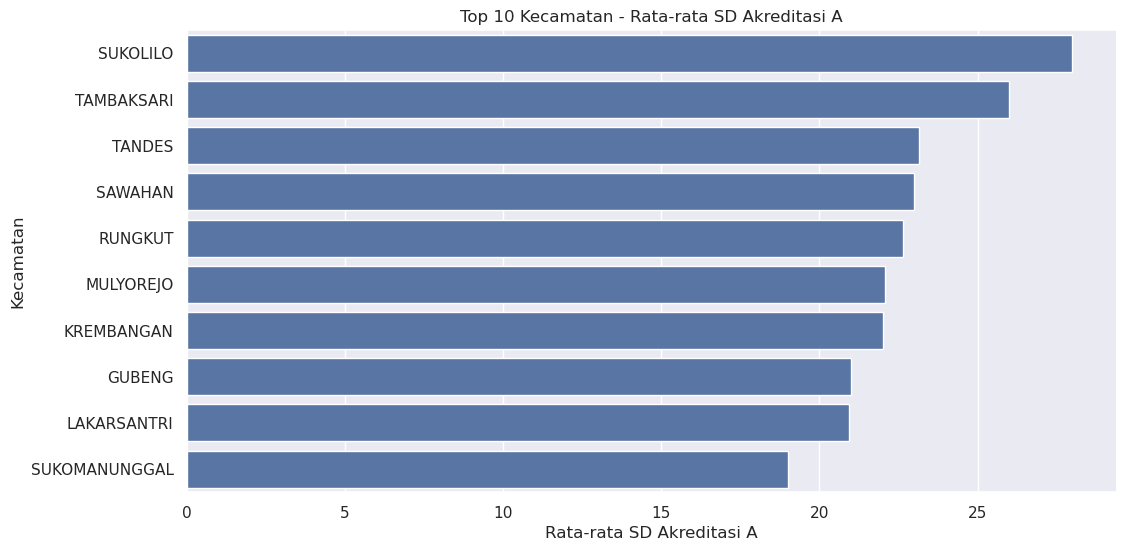

In [7]:
df_agg = df_merge.groupby('Kecamatan')[[
    'Total SD A', 'Total SMP A',
    'Total Sekolah Inklusi', 'Total Siswa Inklusi',
    'Total SD/MI', 'Total SMP/MTS',
    'Umur SD', 'Umur SMP',
    'Jumlah_Faskes', 'Latitude', 'Longitude',
    'Rasio_Faskes_per_1000_Anak'
]].mean().reset_index()

top10_sd = df_agg.sort_values('Total SD A', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_sd, x='Total SD A', y='Kecamatan')
plt.title('Top 10 Kecamatan - Rata-rata SD Akreditasi A')
plt.xlabel('Rata-rata SD Akreditasi A')
plt.ylabel('Kecamatan')
plt.show()

Sukolilo, Tambaksari, dan Tandes mendominasi jumlah SD berakreditasi A di Surabaya. Ketiganya berada di wilayah yang relatif padat dan dekat dengan pusat kota, mengindikasikan korelasi antara aksesibilitas wilayah dengan kualitas akreditasi sekolah.

# ======================================
# ANALISIS 2 : SISWA INKLUSI PER KECAMATAN
# ======================================

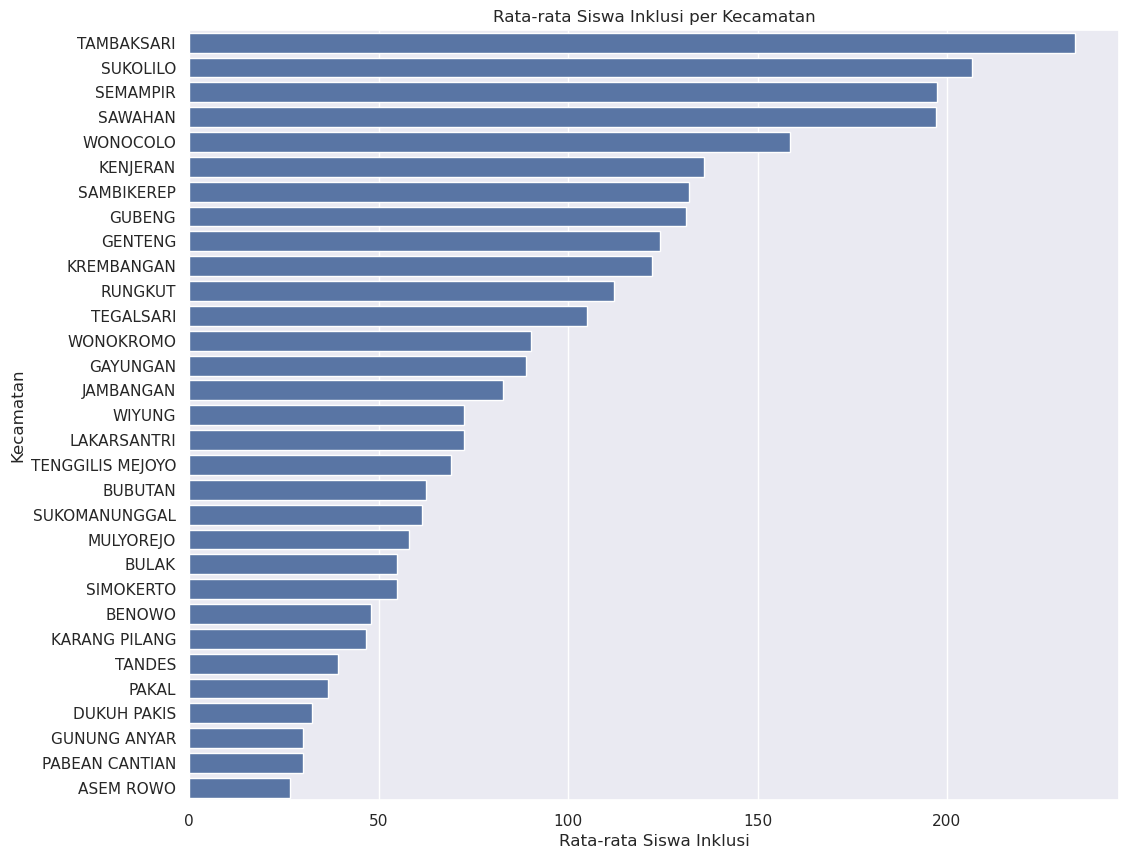

In [8]:
df_all = df_agg.sort_values('Total Siswa Inklusi', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=df_all, x='Total Siswa Inklusi', y='Kecamatan')
plt.title('Rata-rata Siswa Inklusi per Kecamatan')
plt.xlabel('Rata-rata Siswa Inklusi')
plt.ylabel('Kecamatan')
plt.show()

Tambaksari, Sukolilo, dan Semampir mencatat rata-rata siswa inklusi tertinggi. Menariknya, dua kecamatan teratas juga masuk top 3 SD akreditasi A — mengindikasikan bahwa kualitas sekolah dan inklusivitas cenderung berjalan beriringan.

# =====================================
# ANALISIS 3 : KORELASI SD AKREDITASI A VS SEKOLAH INKLUSI
# =======================================

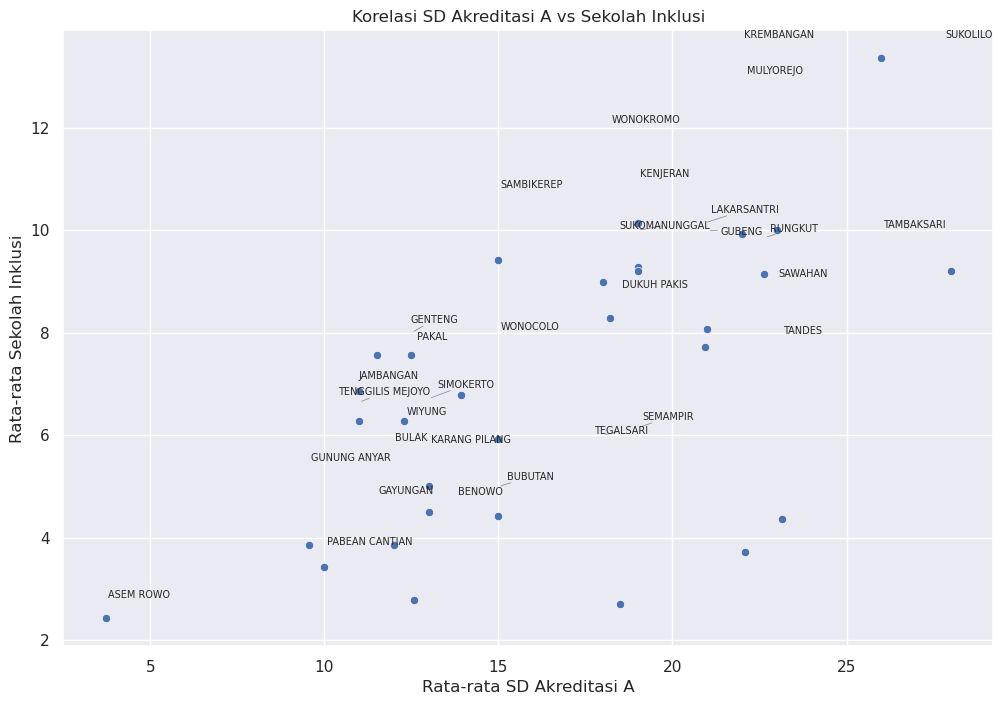

In [9]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df_agg, x='Total SD A', y='Total Sekolah Inklusi')
texts = []
for i, row in df_agg.iterrows():
    texts.append(plt.text(
        row['Total SD A'], 
        row['Total SMP A'], 
        row['Kecamatan'], 
        fontsize=7
    ))

adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)
plt.title('Korelasi SD Akreditasi A vs Sekolah Inklusi')
plt.xlabel('Rata-rata SD Akreditasi A')
plt.ylabel('Rata-rata Sekolah Inklusi')
plt.show()

Terdapat korelasi positif tipis — kecamatan dengan lebih banyak SD akreditasi A cenderung memiliki lebih banyak sekolah inklusi. Namun korelasi tidak kuat, artinya akreditasi tinggi bukan satu-satunya faktor penentu inklusivitas sekolah.

# ======================================
# ANALISIS 4 : PERBANDINGAN TOTAL SD VS SMP PER KECAMATAN
# ======================================

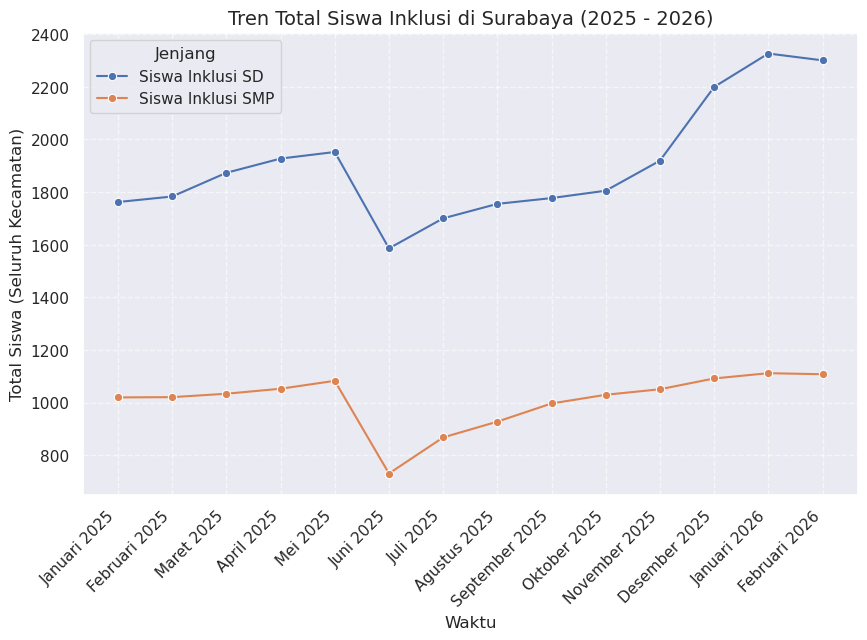

In [10]:
df_merge['Waktu'] = df_merge['Periode'] + " " + df_merge['Tahun'].astype(str)


order = [
    'Januari 2025', 'Februari 2025', 'Maret 2025', 'April 2025',
    'Mei 2025', 'Juni 2025', 'Juli 2025', 'Agustus 2025',
    'September 2025', 'Oktober 2025', 'November 2025', 'Desember 2025',
    'Januari 2026', 'Februari 2026', 'Maret 2026', 'April 2026',
    'Mei 2026', 'Juni 2026', 'Juli 2026', 'Agustus 2026',
    'September 2026', 'Oktober 2026', 'November 2026', 'Desember 2026'
]
df_merge['Waktu'] = pd.Categorical(df_merge['Waktu'], categories=order, ordered=True)


df_melted = df_merge.melt(id_vars=['Kecamatan', 'Waktu'], 
                         value_vars=['Siswa Inklusi SD', 'Siswa Inklusi SMP'],
                         var_name='Jenjang', value_name='Jumlah_Siswa')


plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Waktu', y='Jumlah_Siswa', hue='Jenjang', marker='o', estimator='sum', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Tren Total Siswa Inklusi di Surabaya (2025 - 2026)', fontsize=14)
plt.ylabel('Total Siswa (Seluruh Kecamatan)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


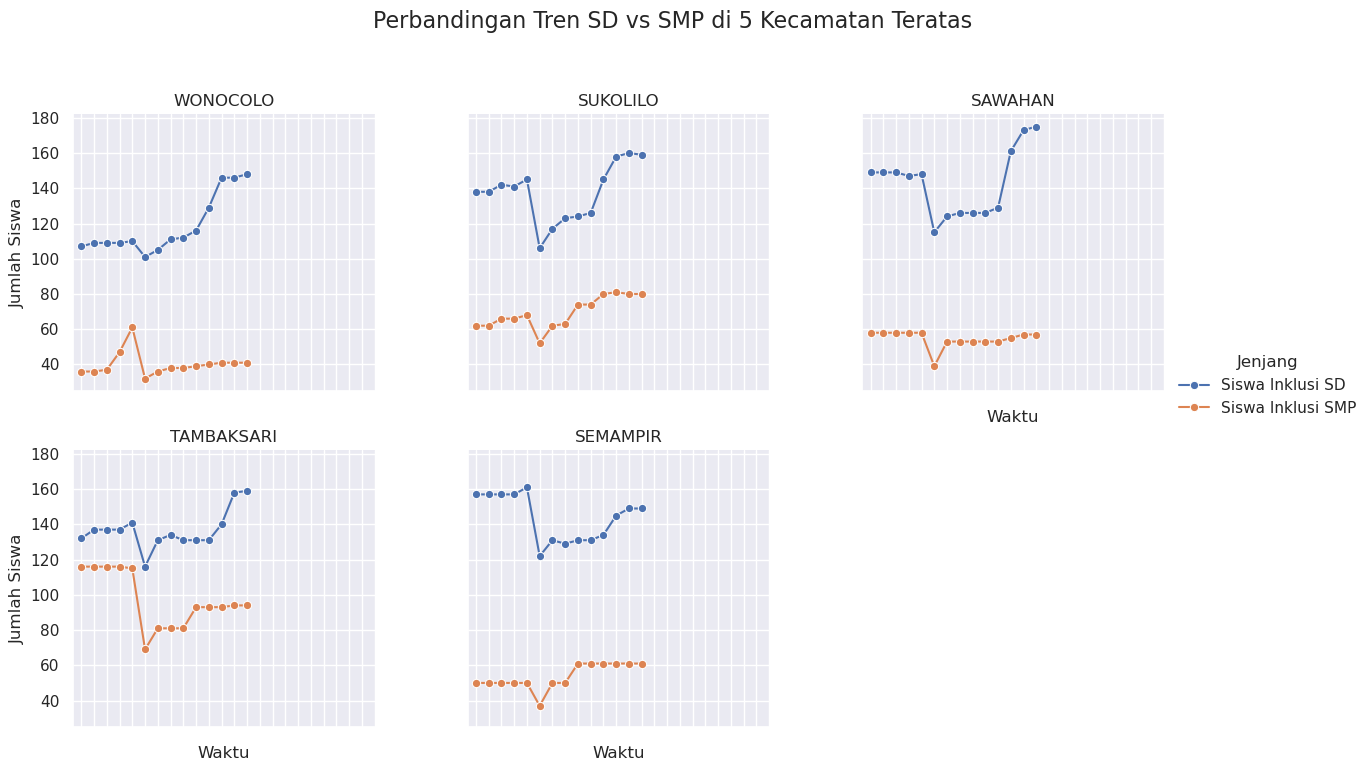

In [11]:
top_5_kec = df_merge.groupby('Kecamatan')['Total Siswa Inklusi'].sum().nlargest(5).index
df_top5 = df_melted[df_melted['Kecamatan'].isin(top_5_kec)]

g = sns.FacetGrid(df_top5, col="Kecamatan", hue="Jenjang", col_wrap=3, height=4)
g.map(sns.lineplot, "Waktu", "Jumlah_Siswa", marker="o")
g.add_legend(title="Jenjang")
g.set_axis_labels("Waktu", "Jumlah Siswa")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Perbandingan Tren SD vs SMP di 5 Kecamatan Teratas', fontsize=16)
plt.savefig('output.png')
plt.show()

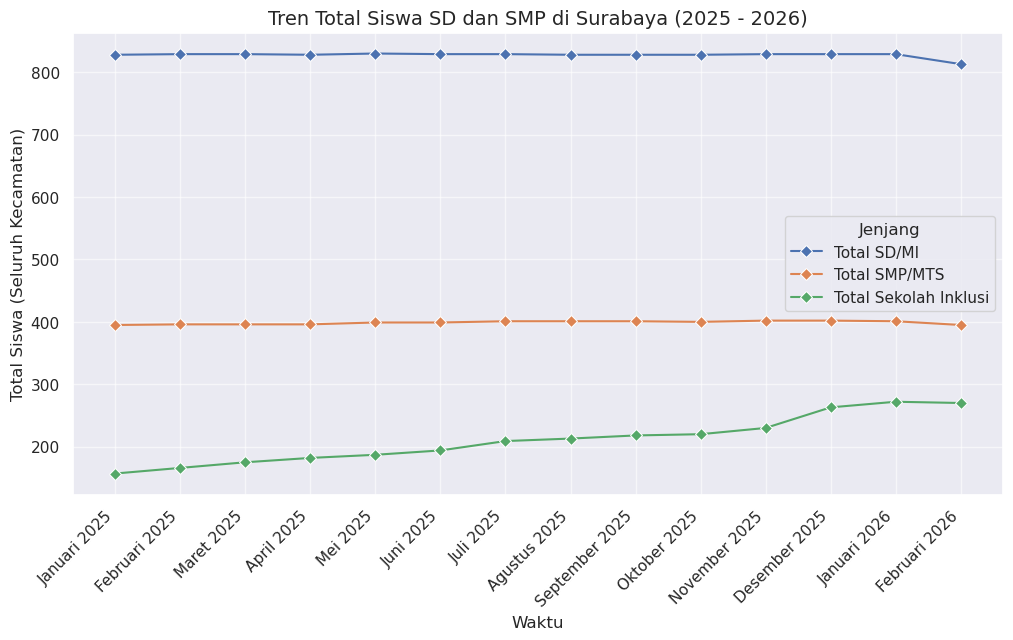

In [12]:
df_melted2 = df_merge.melt(id_vars=['Kecamatan', 'Waktu'], 
                         value_vars=['Total SD/MI', 'Total SMP/MTS', 'Total Sekolah Inklusi'],
                         var_name='Jenjang', value_name='Jumlah_Siswa')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted2, x='Waktu', y='Jumlah_Siswa', hue='Jenjang', marker='D', estimator='sum', errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Tren Total Siswa SD dan SMP di Surabaya (2025 - 2026)', fontsize=14)
plt.ylabel('Total Siswa (Seluruh Kecamatan)')
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig("Tren_Total_Siswa_SD_dan_SMP.png", bbox_inches = "tight", dpi=150)
plt.show()

Jumlah SD dan SMP di Surabaya relatif stabil sepanjang 2025-2026, namun sekolah inklusi menunjukkan tren naik konsisten ~60% dalam setahun. Ini mengindikasikan kebijakan Pemkot Surabaya yang aktif mendorong sekolah reguler untuk mengadopsi program inklusi tanpa perlu membangun sekolah baru.

# ======================================
# ANALISIS 5 : RASIO SEKOLAH INKLUSI PER TOTAL SEKOLAH
# ======================================

--- 10 Data Rasio SD Inklusi Tertinggi (Semua Periode) ---
    Kecamatan    Periode  Tahun  Rasio_SD_Inklusi
312  GAYUNGAN   November   2025         50.000000
219  GAYUNGAN    Agustus   2025         50.000000
343  GAYUNGAN   Desember   2025         50.000000
405  GAYUNGAN   Februari   2026         50.000000
281  GAYUNGAN    Oktober   2025         50.000000
250  GAYUNGAN  September   2025         50.000000
374  GAYUNGAN    Januari   2026         50.000000
157  GAYUNGAN       Juni   2025         46.666667
313  WONOCOLO   November   2025         45.000000
375  WONOCOLO    Januari   2026         45.000000


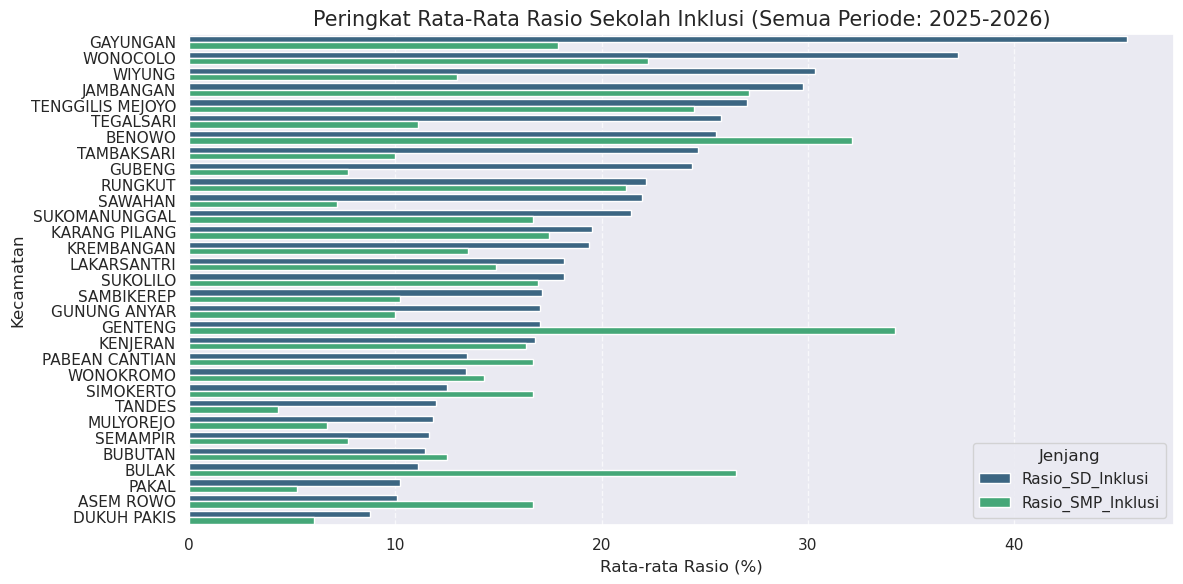

In [13]:
df_merge['Rasio_SD_Inklusi'] = (df_merge['SD Inklusi'] / df_merge['Total SD/MI'].replace(0, float('nan'))) * 100
df_merge['Rasio_SMP_Inklusi'] = (df_merge['SMP Inklusi'] / df_merge['Total SMP/MTS'].replace(0, float('nan'))) * 100
df_sorted = df_merge.sort_values(by='Rasio_SD_Inklusi', ascending=False)
print("--- 10 Data Rasio SD Inklusi Tertinggi (Semua Periode) ---")
print(df_sorted[['Kecamatan', 'Periode', 'Tahun', 'Rasio_SD_Inklusi']].head(10))

df_avg = df_merge.groupby('Kecamatan')[['Rasio_SD_Inklusi', 'Rasio_SMP_Inklusi']].mean().sort_values(by='Rasio_SD_Inklusi', ascending=False).reset_index()
df_plot = df_avg.melt(id_vars='Kecamatan', var_name='Jenjang', value_name='Rasio_Persen')

sns.barplot(data=df_plot, x='Rasio_Persen', y='Kecamatan', hue='Jenjang', palette='viridis')
plt.title('Peringkat Rata-Rata Rasio Sekolah Inklusi (Semua Periode: 2025-2026)', fontsize=15)
plt.xlabel('Rata-rata Rasio (%)')
plt.ylabel('Kecamatan')
plt.legend(title='Jenjang')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Rasio_Sekolah.png",bbox_inches="tight",dpi=150)
plt.show()

Persebaran sekolah inklusi di jenjang SD dan SMP di Surabaya belum merata — Gayungan dan Genteng mendominasi rasio tertinggi, sementara Dukuh Pakis dan Asem Rowo masih jauh tertinggal. Diperlukan kebijakan afirmatif untuk mendorong kecamatan dengan rasio rendah agar mengadopsi program inklusi.

# ======================================
# ANALISIS 6 : HEATMAP KORELASI
# ======================================

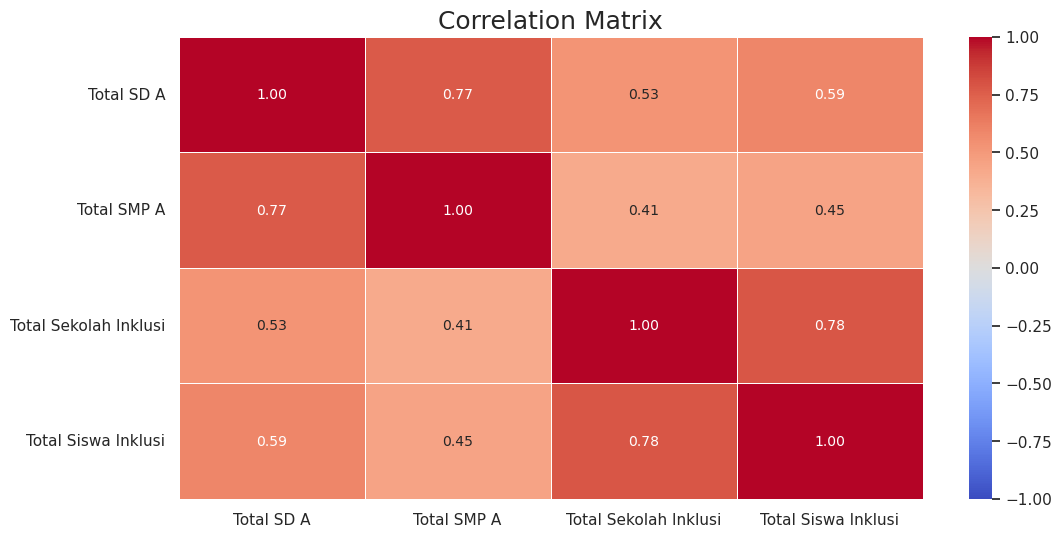

In [14]:
corr = df_merge[['Total SD A', 'Total SMP A', 'Total Sekolah Inklusi', 'Total Siswa Inklusi']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size":10}
)

plt.title("Correlation Matrix", fontsize=18)
plt.savefig('Hubungan_akreditasi_thdp_inklusi.png', bbox_inches="tight", dpi=150)
plt.show()

Kecamatan dengan jumlah SD berakreditasi A yang tinggi cenderung juga memiliki SMP berakreditasi A yang tinggi. 

Namun, hubungan antara kualitas sekolah tersebut dengan keberadaan sekolah inklusi hanya berada pada tingkat sedang dan tidak sekuat hubungan antar jenjang pendidikan umum.

Hal ini mengindikasikan bahwa distribusi pendidikan inklusi tidak sepenuhnya mengikuti pola distribusi sekolah berkualitas, sehingga kemungkinan dipengaruhi oleh faktor lain seperti kebijakan, fasilitas, atau kebutuhan wilayah.

Temuan ini menunjukkan pentingnya pendekatan kebijakan yang lebih spesifik dalam pemerataan pendidikan inklusif di setiap wilayah.

# ======================================
# ANALISIS 7 : KETIMPANGAN DISTRIBUSI PENDIDIKAN
# ======================================

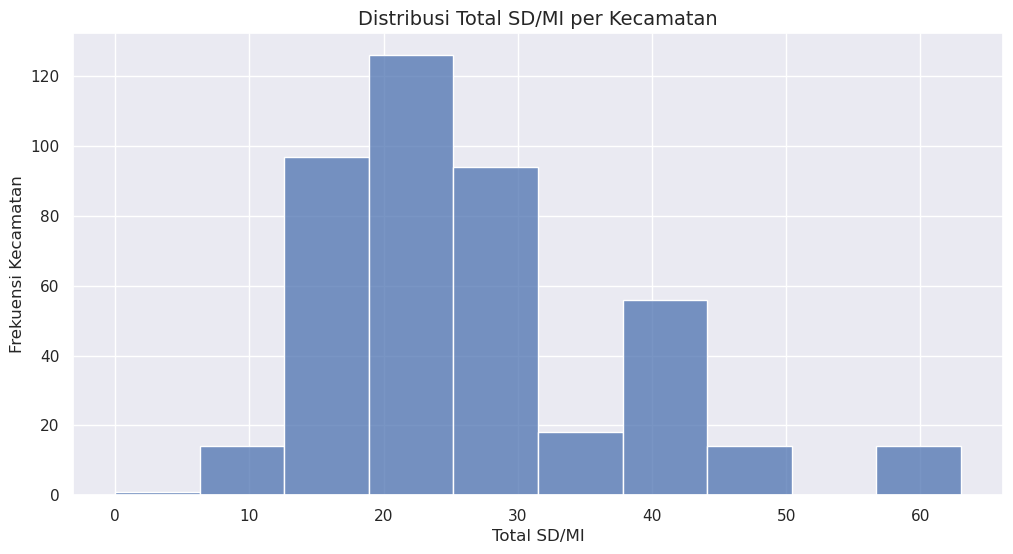

In [15]:
sns.histplot(df_merge['Total SD/MI'], bins=10)
plt.title("Distribusi Total SD/MI per Kecamatan", fontsize=14)
plt.xlabel("Total SD/MI")
plt.ylabel("Frekuensi Kecamatan")
plt.savefig("Distribusi_Pendidikan_Dasar.png", bbox_inches="tight", dpi =150)
plt.show()

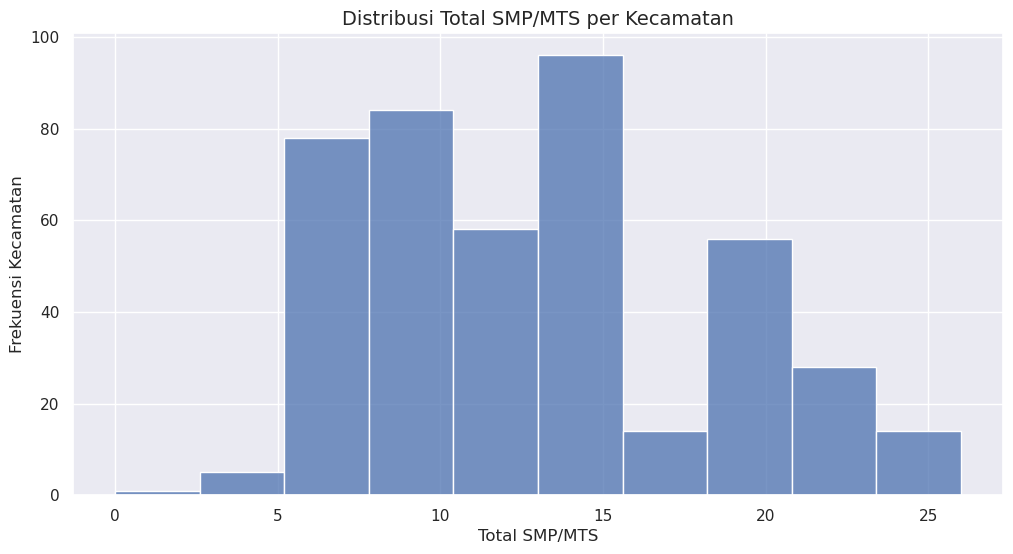

In [16]:
sns.histplot(df_merge['Total SMP/MTS'], bins=10)
plt.title("Distribusi Total SMP/MTS per Kecamatan", fontsize=14)
plt.xlabel("Total SMP/MTS")
plt.ylabel("Frekuensi Kecamatan")
plt.savefig("Distribusi_Pendidikan_Menengah_Pertama.png", bbox_inches="tight", dpi =150)
plt.show()

# ======================================
# ANALISIS 8 : OUTLIER DETECTION
# ======================================

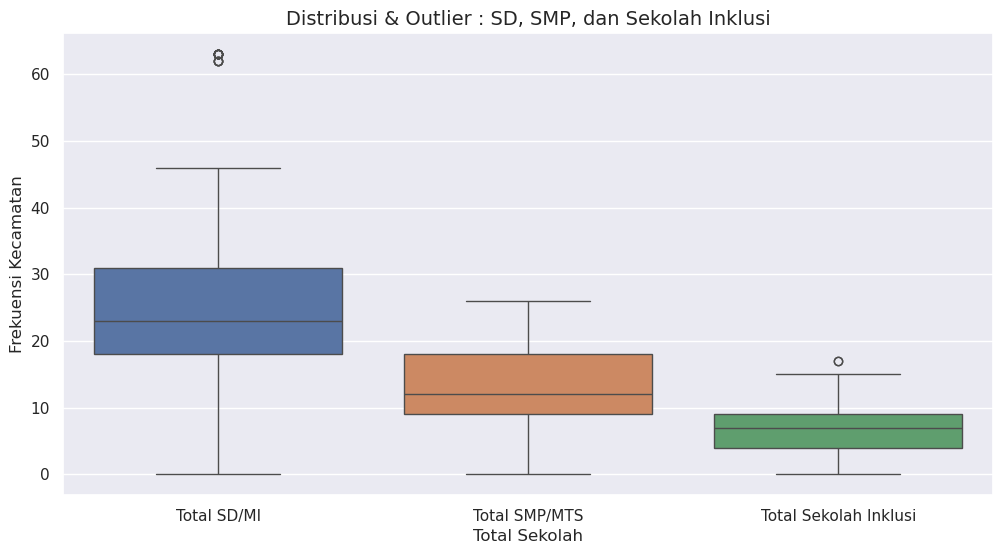

In [17]:
sns.boxplot(data=df_merge[['Total SD/MI', 'Total SMP/MTS', 'Total Sekolah Inklusi']])
plt.title("Distribusi & Outlier : SD, SMP, dan Sekolah Inklusi", fontsize=14)
plt.xlabel("Total Sekolah")
plt.ylabel("Frekuensi Kecamatan")
plt.savefig("Distribusi&Outlier.png",bbox_inches="tight", dpi=150)
plt.show()

Ketimpangan pada jenjang SD/MI menunjukkan bahwa akses pendidikan dasar belum sepenuhnya merata, dengan indikasi adanya penumpukan fasilitas di wilayah tertentu. 

Sementara itu, distribusi SMP/MTS yang lebih stabil menunjukkan bahwa pemerataan pada jenjang menengah sudah relatif lebih baik.

Kondisi ini mengindikasikan adanya potensi bottleneck pada fase pendidikan dasar, yang dapat berdampak pada ketidaksetaraan akses sejak tahap paling awal dalam sistem pendidikan.

# ======================================
# ANALISIS 9 : KORELASI SD VS SMP AKREDITASI A
# ======================================

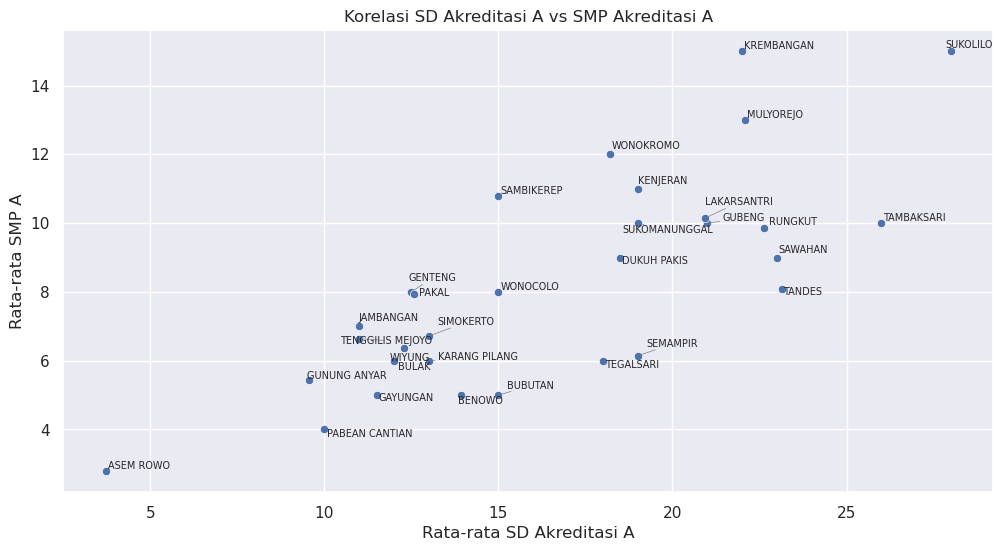

In [18]:
sns.scatterplot(data=df_agg, x='Total SD A', y='Total SMP A')

texts = []
for i, row in df_agg.iterrows():
    texts.append(plt.text(
        row['Total SD A'], 
        row['Total SMP A'], 
        row['Kecamatan'], 
        fontsize=7
    ))

adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.title('Korelasi SD Akreditasi A vs SMP Akreditasi A')
plt.xlabel('Rata-rata SD Akreditasi A')
plt.ylabel('Rata-rata SMP A')
plt.savefig("SDvsSMPA.png", bbox_inches="tight",dpi=150)
plt.show()

Terdapat korelasi positif yang kuat antara jumlah SD dan SMP berakreditasi A per kecamatan, di mana wilayah dengan SD berkualitas tinggi cenderung juga memiliki SMP berkualitas tinggi. Sukolilo dan Tambaksari menjadi contoh kecamatan dengan nilai tinggi pada kedua jenjang tersebut.

Namun, terdapat beberapa penyimpangan dari pola umum. Krembangan menunjukkan jumlah SMP berakreditasi A yang relatif lebih tinggi dibandingkan jumlah SD-nya, sementara Pabean Cantian menunjukkan kesenjangan yang cukup besar antar jenjang. Asem Rowo berada pada tingkat rendah di kedua jenjang dan dapat menjadi salah satu wilayah yang perlu mendapat perhatian lebih lanjut.

Temuan ini mengindikasikan bahwa peningkatan kualitas pendidikan di Surabaya belum sepenuhnya merata dan masih cenderung terkonsentrasi pada wilayah tertentu, sehingga diperlukan pendekatan kebijakan yang lebih terarah untuk mengurangi kesenjangan antar kecamatan.

# ======================================
# ANALISIS 10 : INKLUSI VS TOTAL SEKOLAH
# ======================================

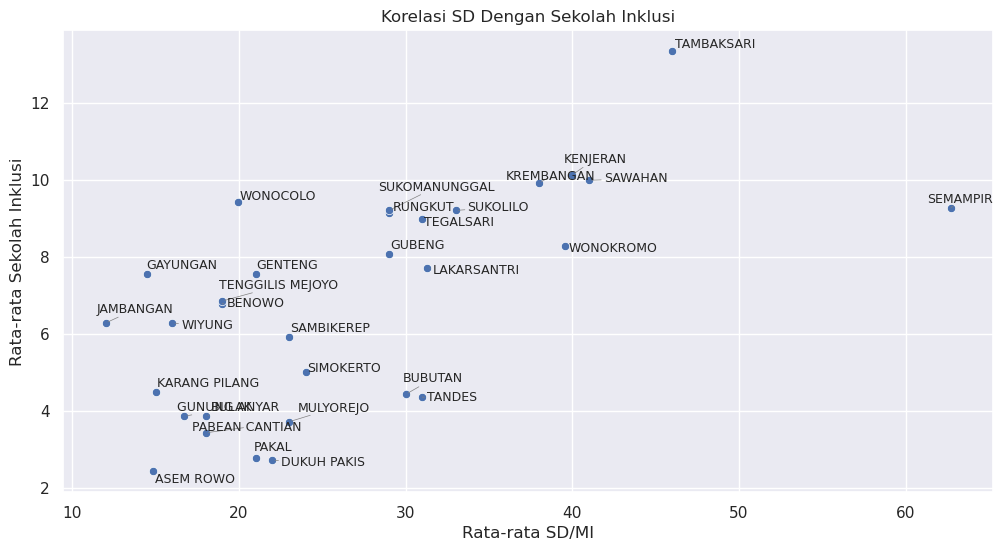

In [19]:
df_agg = df_merge.groupby('Kecamatan')[[
    'Total SD A', 'Total SMP A',
    'Total Sekolah Inklusi', 'Total Siswa Inklusi',
    'Total SD/MI', 'Total SMP/MTS',
    'Umur SD', 'Umur SMP',
    'Jumlah_Faskes', 'Latitude', 'Longitude',        # ← dari analisis 1
    'Rasio_Faskes_per_1000_Anak'                      # ← baru
]].mean().reset_index()

sns.scatterplot(data=df_agg, x='Total SD/MI', y='Total Sekolah Inklusi')

texts = []
for i, row in df_agg.iterrows():
    texts.append(plt.text(
        row['Total SD/MI'], 
        row['Total Sekolah Inklusi'], 
        row['Kecamatan'], 
        fontsize=9
    ))

adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.title('Korelasi SD Dengan Sekolah Inklusi')
plt.xlabel('Rata-rata SD/MI')
plt.ylabel('Rata-rata Sekolah Inklusi')
plt.savefig("SDvsInklusi.png", bbox_inches="tight",dpi=150)
plt.show()

Hubungan antara jumlah SD/MI dan sekolah inklusi di Surabaya menunjukkan korelasi yang cenderung lemah hingga sedang. 

Meskipun terdapat kecenderungan peningkatan jumlah sekolah inklusi seiring bertambahnya jumlah SD/MI, pola tersebut tidak konsisten di seluruh kecamatan. Semampir menjadi salah satu outlier yang mencolok — dengan jumlah SD/MI tertinggi (~63), namun jumlah sekolah inklusinya relatif lebih rendah (~9), di bawah Tambaksari yang memiliki SD/MI lebih sedikit (~46) tetapi tingkat inklusi lebih tinggi (~13).

Temuan ini mengindikasikan bahwa banyaknya sekolah tidak secara langsung menentukan tingkat inklusivitas. Faktor lain seperti kebijakan wilayah, ketersediaan tenaga pendamping, serta kesiapan institusi kemungkinan memiliki peran yang lebih signifikan.

Hal ini menunjukkan bahwa peningkatan jumlah sekolah saja tidak cukup untuk mendorong pendidikan inklusif, sehingga diperlukan pendekatan kebijakan yang lebih spesifik dan terarah.

# ======================================
# ANALISIS 11 : RASIO SD PER 1000 ANAK USIA SD
# ======================================

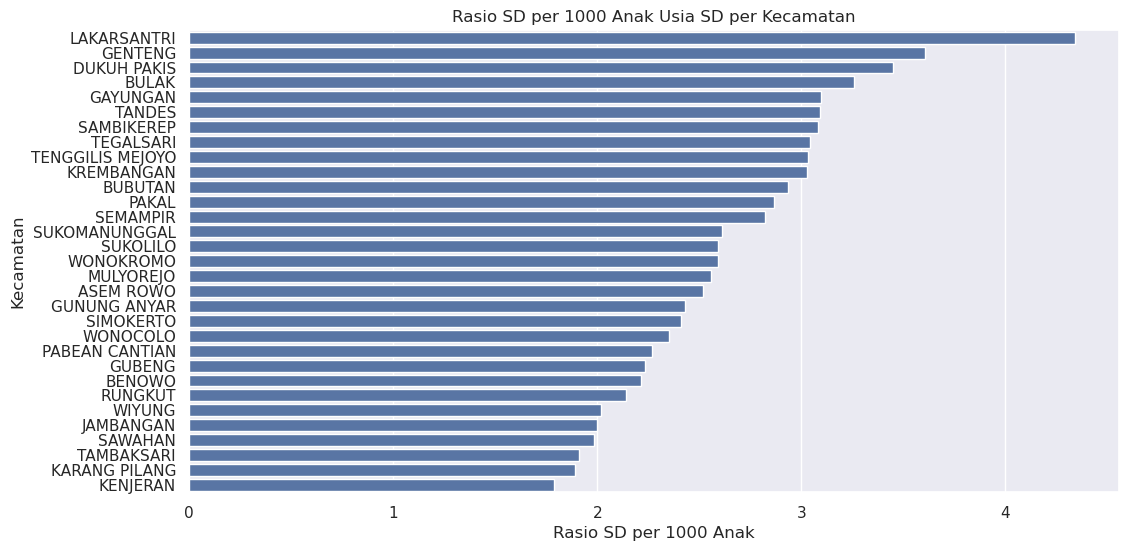

In [20]:
df_agg['Rasio_SD_per_1000'] = df_agg.apply(
    lambda x: (x['Total SD/MI'] / x['Umur SD']) * 1000 if x['Umur SD'] > 0 else 0, axis=1
)

df_sorted = df_agg.sort_values('Rasio_SD_per_1000', ascending=False)

sns.barplot(data=df_sorted, x='Rasio_SD_per_1000', y='Kecamatan')
plt.title('Rasio SD per 1000 Anak Usia SD per Kecamatan')
plt.xlabel('Rasio SD per 1000 Anak')
plt.ylabel('Kecamatan')
plt.savefig("Rasio_SD.png", bbox_inches="tight", dpi=150)
plt.show()

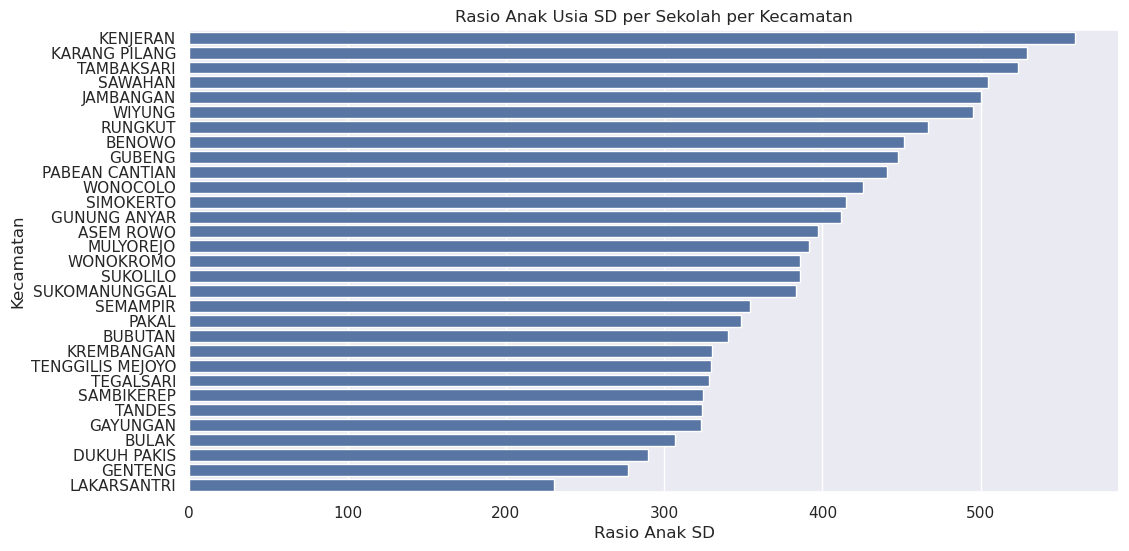

In [21]:
df_agg['Anak_per_SD'] = df_agg.apply(
    lambda x: x['Umur SD'] / x['Total SD/MI'] if x['Total SD/MI'] > 0 else 0, axis=1
)

df_sorted = df_agg.sort_values('Anak_per_SD', ascending=False)

sns.barplot(data=df_sorted, x='Anak_per_SD', y='Kecamatan')
plt.title('Rasio Anak Usia SD per Sekolah per Kecamatan')
plt.xlabel('Rasio Anak SD')
plt.ylabel('Kecamatan')
plt.savefig("Rasio_Anak_SD.png", bbox_inches="tight", dpi=150)
plt.show()

Analisis rasio menunjukkan adanya ketimpangan akses pendidikan dasar antar kecamatan di Surabaya. Kecamatan seperti Kenjeran dan Karang Pilang memiliki jumlah anak per sekolah yang tinggi, mengindikasikan beban kapasitas yang lebih besar dibanding wilayah lain. Sebaliknya, Lakarsantri dan Genteng menunjukkan rasio sekolah per anak yang lebih tinggi, menandakan ketersediaan fasilitas yang relatif lebih memadai.

Temuan ini menegaskan bahwa jumlah sekolah secara absolut tidak cukup untuk menggambarkan kecukupan layanan pendidikan. Wilayah dengan jumlah sekolah yang terlihat tinggi pun dapat tetap mengalami tekanan kapasitas apabila tidak sebanding dengan jumlah anak usia sekolah. Oleh karena itu, perencanaan pendidikan perlu mempertimbangkan rasio kebutuhan terhadap fasilitas, bukan hanya distribusi jumlah sekolah.

Temuan ini relevan bagi pengambil kebijakan dalam mengalokasikan anggaran pembangunan sekolah baru — prioritas seharusnya diberikan kepada kecamatan dengan rasio anak per sekolah tertinggi, bukan sekadar yang secara absolut memiliki sekolah paling sedikit.

# ======================================
# ANALISIS 12 : RASIO SMP PER 1000 ANAK USIA SMP
# ======================================

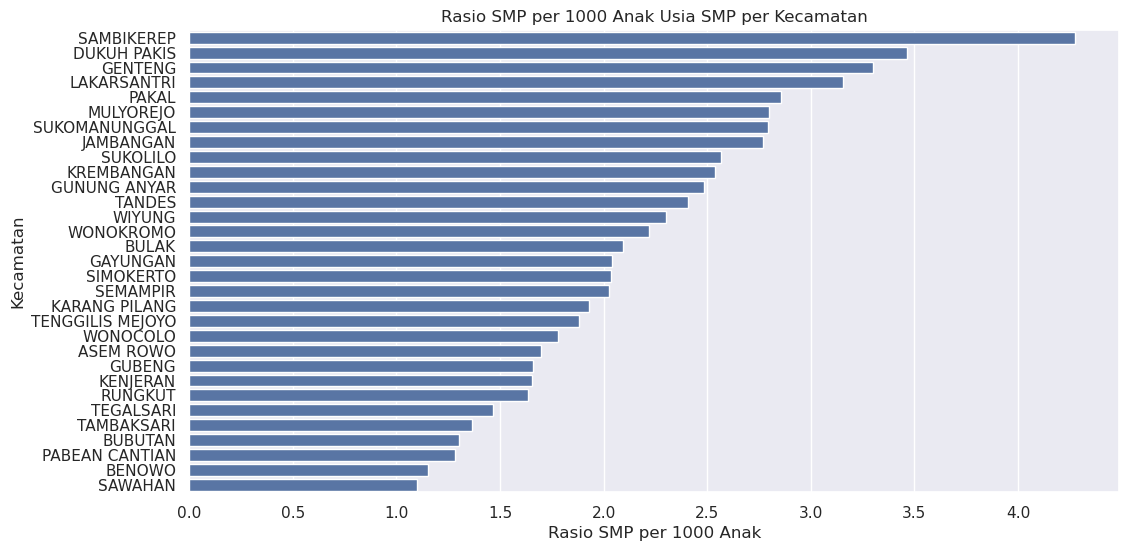

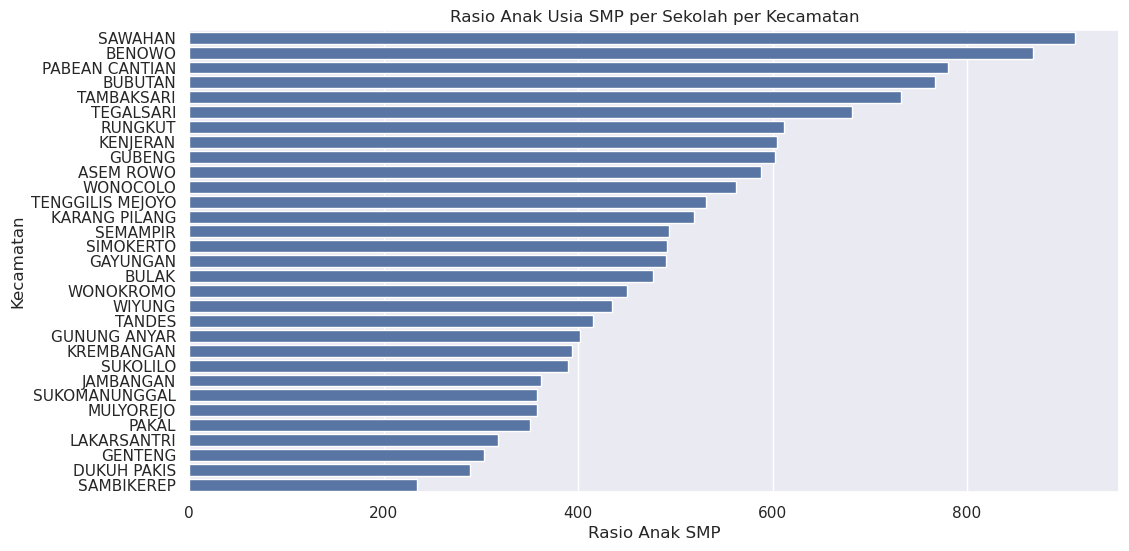

In [22]:
df_agg['Rasio_SMP_per_1000'] = df_agg.apply(
    lambda x: (x['Total SMP/MTS'] / x['Umur SMP']) * 1000 if x['Umur SMP'] > 0 else 0, axis=1
)

df_sorted2 = df_agg.sort_values('Rasio_SMP_per_1000', ascending=False)

sns.barplot(data=df_sorted2, x='Rasio_SMP_per_1000', y='Kecamatan')
plt.title('Rasio SMP per 1000 Anak Usia SMP per Kecamatan')
plt.xlabel('Rasio SMP per 1000 Anak')
plt.ylabel('Kecamatan')
plt.savefig("Rasio_SMP.png", bbox_inches="tight", dpi=150)
plt.show()

df_agg['Anak_per_SMP'] = df_agg.apply(
    lambda x: x['Umur SMP'] / x['Total SMP/MTS'] if x['Total SMP/MTS'] > 0 else 0, axis=1
)

df_sorted = df_agg.sort_values('Anak_per_SMP', ascending=False)

sns.barplot(data=df_sorted, x='Anak_per_SMP', y='Kecamatan')
plt.title('Rasio Anak Usia SMP per Sekolah per Kecamatan')
plt.xlabel('Rasio Anak SMP')
plt.ylabel('Kecamatan')
plt.savefig("Rasio_Anak_SMP.png", bbox_inches="tight", dpi=150)
plt.show()

Analisis rasio menunjukkan adanya ketimpangan akses pendidikan SMP antar kecamatan di Surabaya. Kecamatan seperti Sawahan, Benowo, dan Pabean Cantian memiliki jumlah anak per sekolah yang relatif tinggi serta rasio sekolah per 1000 anak yang lebih rendah, mengindikasikan tekanan kapasitas yang lebih besar. 

Sebaliknya, wilayah seperti Sambikerep dan Dukuh Pakis menunjukkan rasio yang lebih seimbang, dengan ketersediaan sekolah yang relatif lebih memadai terhadap jumlah anak usia SMP. 

Temuan ini menegaskan bahwa jumlah sekolah secara absolut tidak cukup untuk menilai kecukupan layanan pendidikan. Perencanaan yang lebih efektif perlu mempertimbangkan rasio antara kebutuhan dan kapasitas, bukan hanya distribusi jumlah fasilitas.

Pola yang sama dengan jenjang SD terulang di tingkat SMP — rasio berbasis kebutuhan terbukti lebih representatif dari jumlah absolut. Namun menariknya, kecamatan yang mengalami tekanan kapasitas di jenjang SMP tidak selalu sama dengan yang tertekan di SD, menunjukkan bahwa masalah kapasitas tiap jenjang perlu ditangani secara terpisah.

# ======================================
# ANALISIS 13 : KECAMATAN DOUBLE PRESSURE
# ======================================

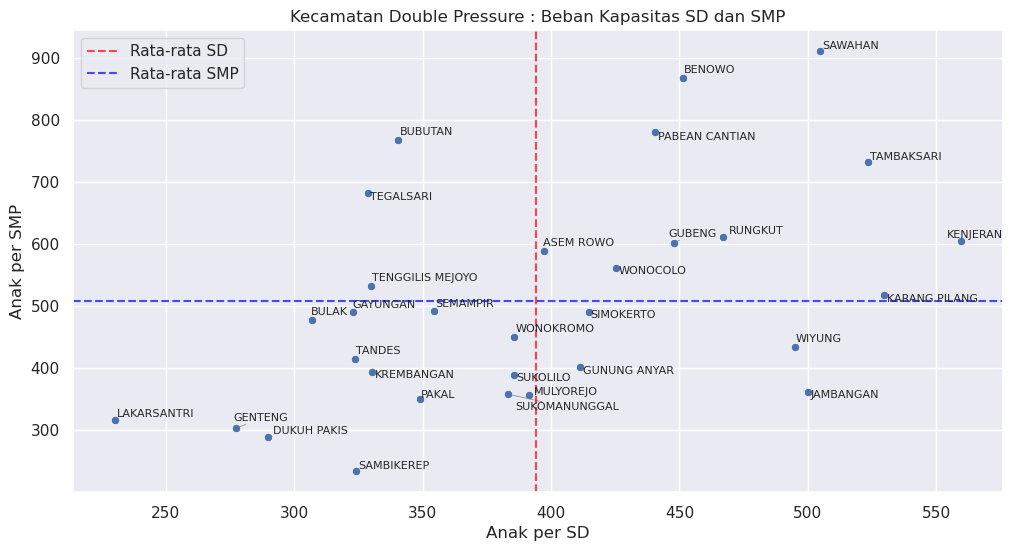

In [23]:
sns.scatterplot(data=df_agg, x='Anak_per_SD', y='Anak_per_SMP')


plt.axvline(df_agg['Anak_per_SD'].mean(), color='red', linestyle='--', alpha=0.7, label='Rata-rata SD')
plt.axhline(df_agg['Anak_per_SMP'].mean(), color='blue', linestyle='--', alpha=0.7, label='Rata-rata SMP')


texts = []
for i, row in df_agg.iterrows():
    texts.append(plt.text(
        row['Anak_per_SD'],
        row['Anak_per_SMP'],
        row['Kecamatan'],
        fontsize=8
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title('Kecamatan Double Pressure : Beban Kapasitas SD dan SMP')
plt.xlabel('Anak per SD')
plt.ylabel('Anak per SMP')
plt.legend()
plt.savefig("Double_Pressure.png", bbox_inches="tight", dpi=150)
plt.show()

Analisis double pressure menunjukkan bahwa beberapa kecamatan mengalami tekanan kapasitas secara simultan pada jenjang SD dan SMP. Kecamatan seperti Sawahan, Benowo, dan Pabean Cantian berada pada kuadran dengan beban tinggi di kedua jenjang, menjadikannya prioritas utama dalam perencanaan pendidikan.

Menariknya, beberapa kecamatan dengan jumlah sekolah yang relatif tinggi seperti Tambaksari dan Kenjeran tetap berada dalam zona tekanan, menegaskan bahwa ketersediaan fasilitas tidak dapat dinilai hanya dari jumlah absolut, melainkan harus mempertimbangkan rasio terhadap populasi usia sekolah.

Temuan ini menunjukkan bahwa ketimpangan akses pendidikan di Surabaya bersifat struktural dan memerlukan pendekatan berbasis kebutuhan, bukan sekadar distribusi jumlah sekolah.

Sebaliknya, kecamatan seperti Lakarsantri, Genteng, dan Sambikerep berada di kuadran double advantage — tekanan kapasitas rendah di kedua jenjang. Disparitas antara kuadran ini menunjukkan bahwa redistribusi sumber daya antar wilayah berpotensi lebih efektif dibanding pembangunan fasilitas baru secara merata.

# ======================================
# ANALISIS 14 : GAP ANTAR JENJANG SD VS SMP
# ======================================

=== DISTRIBUSI GAP ===
           Kecamatan  Gap_SD_SMP
2            BUBUTAN   -1.632851
26         TEGALSARI   -1.576400
13       LAKARSANTRI   -1.187072
3              BULAK   -1.162148
27  TENGGILIS MEJOYO   -1.152517
1             BENOWO   -1.063744
5           GAYUNGAN   -1.054090
15    PABEAN CANTIAN   -0.987524
19           SAWAHAN   -0.883661
0          ASEM ROWO   -0.817664
20          SEMAMPIR   -0.792250
25            TANDES   -0.680083
29          WONOCOLO   -0.572317
7             GUBENG   -0.571478
24        TAMBAKSARI   -0.544762
17           RUNGKUT   -0.507855
12        KREMBANGAN   -0.485951
21         SIMOKERTO   -0.374916
30         WONOKROMO   -0.373468
6            GENTENG   -0.305351
11          KENJERAN   -0.132384
22          SUKOLILO   -0.025956
16             PAKAL   -0.011364
4        DUKUH PAKIS    0.012534
10     KARANG PILANG    0.038915
8       GUNUNG ANYAR    0.055245
23     SUKOMANUNGGAL    0.184011
14         MULYOREJO    0.242192
28            WIYUNG

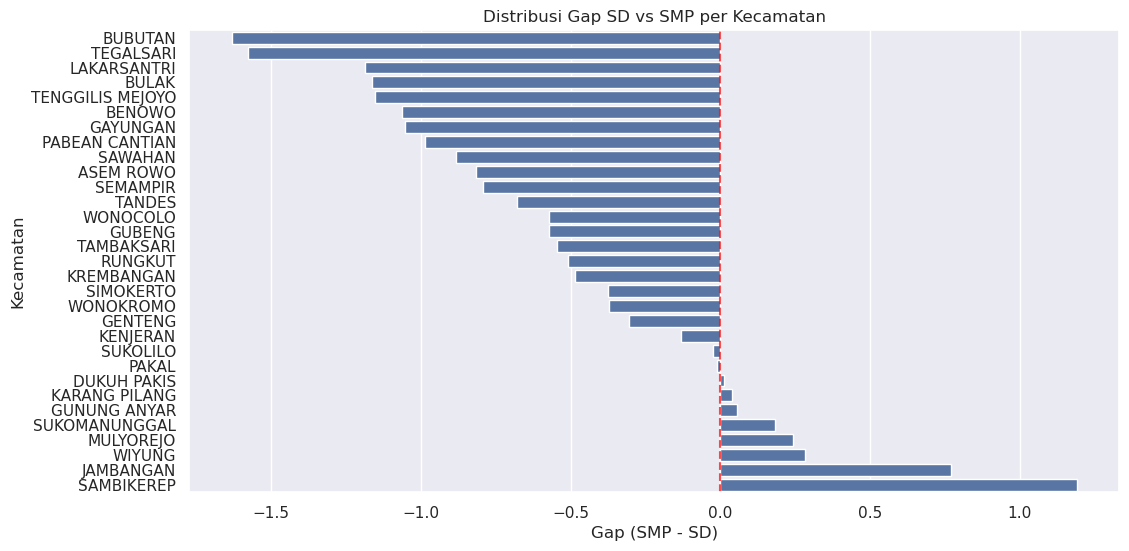

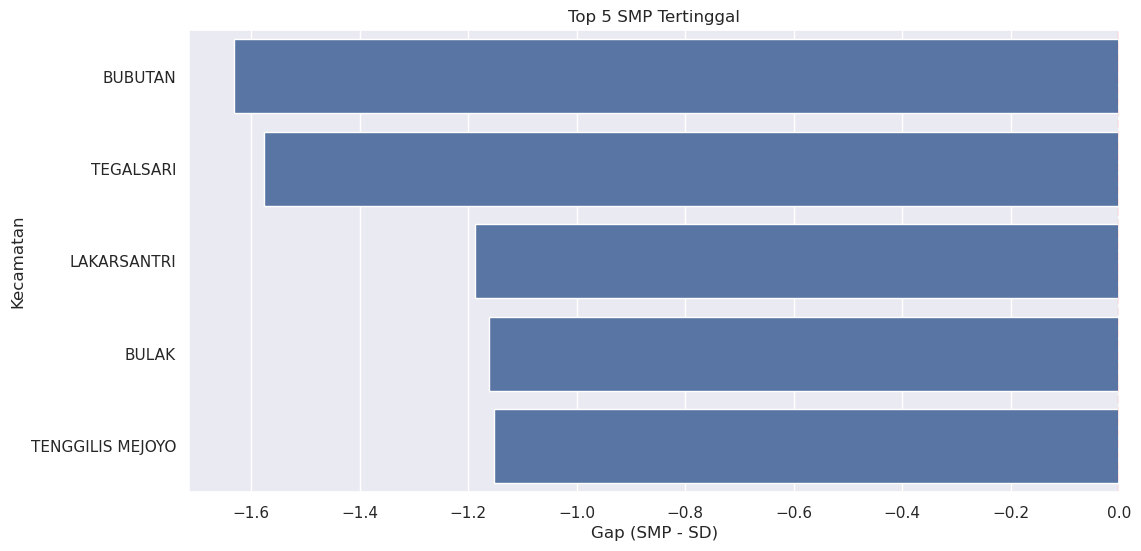

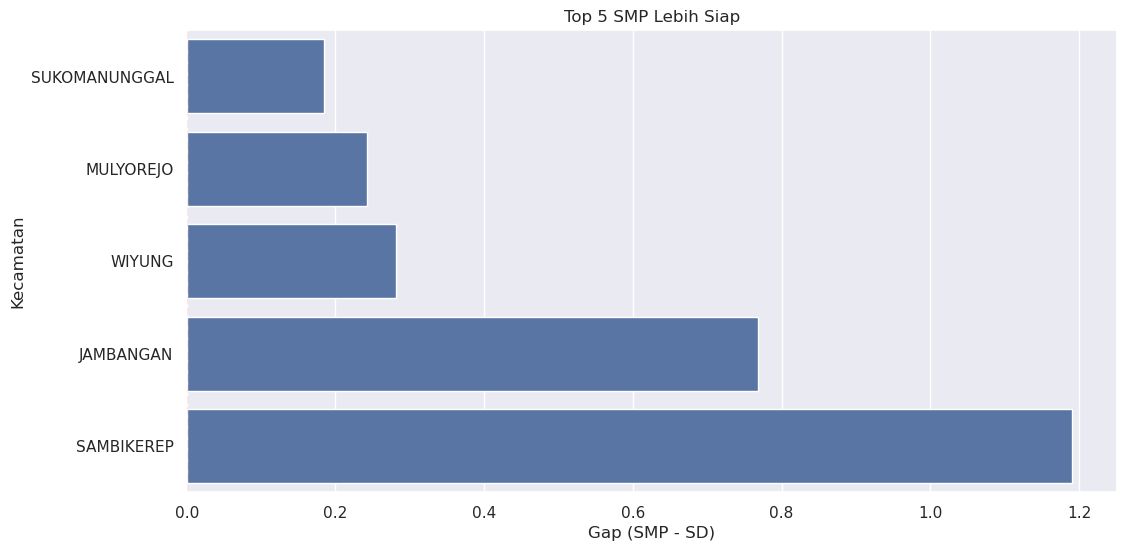

In [24]:
# ==============================
# HITUNG GAP
# ==============================

df_agg["Gap_SD_SMP"] = df_agg["Rasio_SMP_per_1000"] - df_agg["Rasio_SD_per_1000"]

df_sorted = df_agg.sort_values("Gap_SD_SMP")

print("=== DISTRIBUSI GAP ===")
print(df_sorted[["Kecamatan", "Gap_SD_SMP"]])

# ==============================
# TOP & BOTTOM
# ==============================

bottom5 = df_sorted.head(5)
top5    = df_sorted.tail(5)

print("\n=== TOP 5 SMP TERTINGGAL ===")
print(bottom5[["Kecamatan", "Gap_SD_SMP"]])

print("\n=== TOP 5 SMP LEBIH SIAP ===")
print(top5[["Kecamatan", "Gap_SD_SMP"]])

# ==============================
# KATEGORI GAP
# ==============================

df_agg["Kategori_Gap"] = pd.cut(
    df_agg["Gap_SD_SMP"],
    bins=[-999, -0.5, 0.5, 999],
    labels=["SMP Tertinggal", "Seimbang", "SMP Lebih Siap"]
)

# ==============================
# 1. DISTRIBUSI FULL
# ==============================

sns.barplot(data=df_sorted, x="Gap_SD_SMP", y="Kecamatan")
plt.axvline(0, linestyle="--", color="red", alpha=0.7)
plt.title("Distribusi Gap SD vs SMP per Kecamatan")
plt.xlabel("Gap (SMP - SD)")
plt.ylabel("Kecamatan")
plt.savefig("gap_full.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# 2. BOTTOM 5
# ==============================

sns.barplot(data=bottom5, x="Gap_SD_SMP", y="Kecamatan")
plt.axvline(0, linestyle="--", color="red", alpha=0.7)
plt.title("Top 5 SMP Tertinggal")
plt.xlabel("Gap (SMP - SD)")
plt.ylabel("Kecamatan")
plt.savefig("gap_bottom5.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# 3. TOP 5
# ==============================

sns.barplot(data=top5, x="Gap_SD_SMP", y="Kecamatan")
plt.axvline(0, linestyle="--", color="red", alpha=0.7)
plt.title("Top 5 SMP Lebih Siap")
plt.xlabel("Gap (SMP - SD)")
plt.ylabel("Kecamatan")
plt.savefig("gap_top5.png", bbox_inches="tight", dpi=150)
plt.show()

Analisis gap antar jenjang menunjukkan bahwa secara umum kapasitas SMP di Surabaya belum sepenuhnya mengimbangi kapasitas SD, dengan mayoritas kecamatan berada pada kondisi gap negatif. Hal ini mengindikasikan adanya potensi bottleneck pada transisi pendidikan dari SD ke SMP.

Kecamatan seperti Bubutan, Tegalsari, dan Lakarsantri menunjukkan ketimpangan yang paling signifikan, di mana kesiapan SD tidak diikuti oleh kapasitas SMP yang memadai. Kondisi ini berpotensi menyebabkan penumpukan siswa pada jenjang lanjutan.

Di sisi lain, kecamatan seperti Sambikerep dan Jambangan justru memiliki kapasitas SMP yang relatif lebih longgar, mengindikasikan adanya peluang redistribusi atau optimalisasi daya tampung.

Temuan ini menegaskan bahwa perencanaan pendidikan tidak cukup hanya berfokus pada jumlah sekolah, namun juga harus mempertimbangkan keseimbangan antar jenjang untuk memastikan transisi pendidikan yang lancar.

# ======================================
# ANALISIS 15 : KONSISTENSI ANTAR JENJANG
# ======================================

=== DISTRIBUSI KETIDAKKONSISTENAN ===
           Kecamatan  Consistency
2            BUBUTAN     1.632851
26         TEGALSARI     1.576400
18        SAMBIKEREP     1.191168
13       LAKARSANTRI     1.187072
3              BULAK     1.162148
27  TENGGILIS MEJOYO     1.152517
1             BENOWO     1.063744
5           GAYUNGAN     1.054090
15    PABEAN CANTIAN     0.987524
19           SAWAHAN     0.883661
0          ASEM ROWO     0.817664
20          SEMAMPIR     0.792250
9          JAMBANGAN     0.768783
25            TANDES     0.680083
29          WONOCOLO     0.572317
7             GUBENG     0.571478
24        TAMBAKSARI     0.544762
17           RUNGKUT     0.507855
12        KREMBANGAN     0.485951
21         SIMOKERTO     0.374916
30         WONOKROMO     0.373468
6            GENTENG     0.305351
28            WIYUNG     0.281761
14         MULYOREJO     0.242192
23     SUKOMANUNGGAL     0.184011
11          KENJERAN     0.132384
8       GUNUNG ANYAR     0.055245
10     KAR

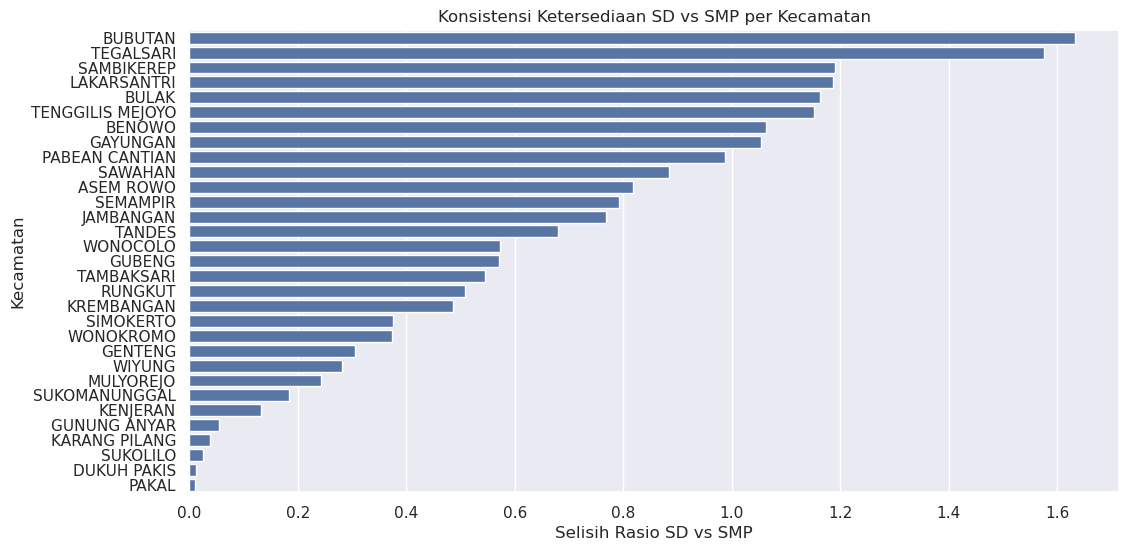

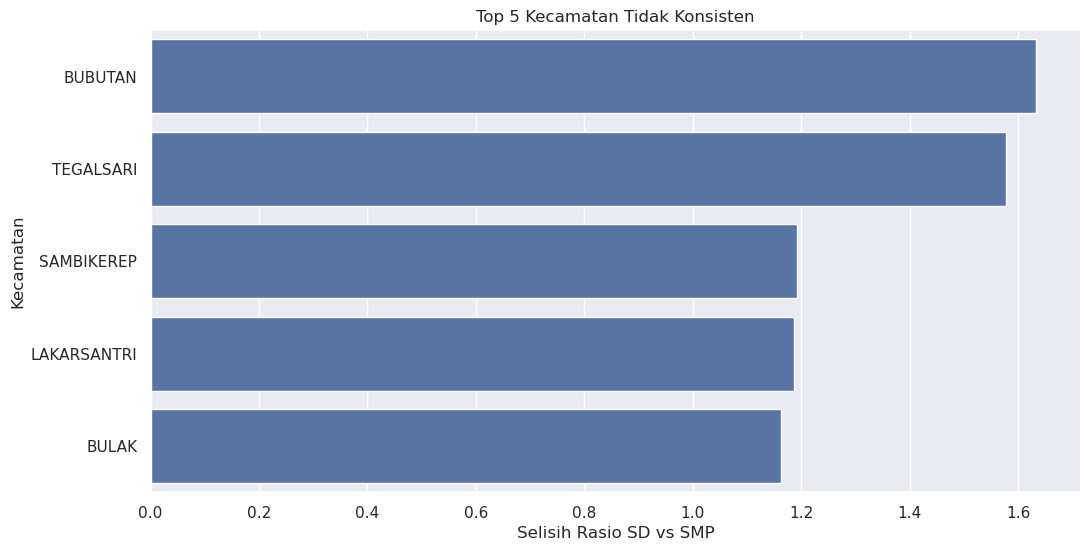

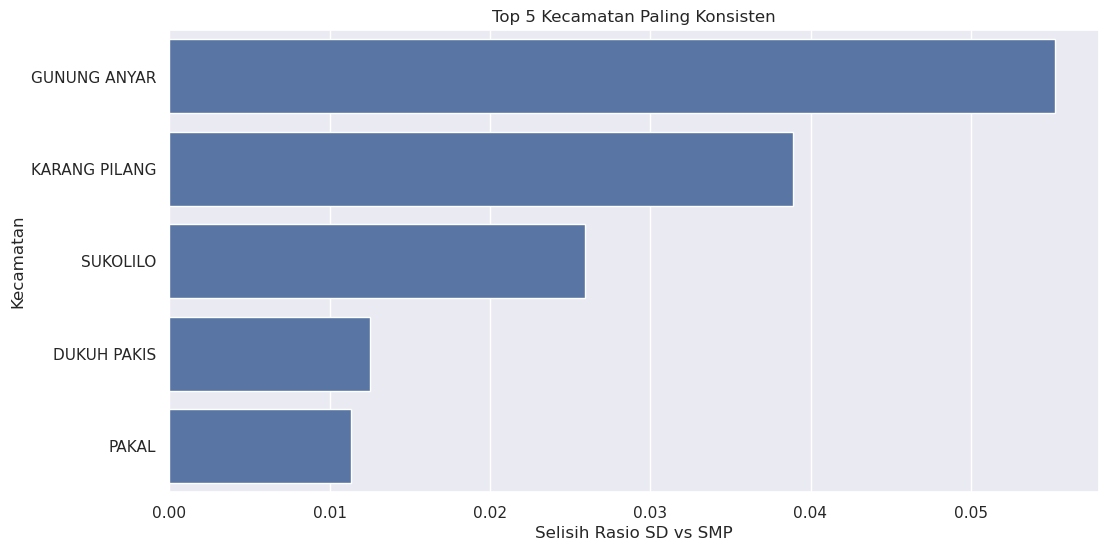

In [25]:
# ==============================
# HITUNG KONSISTENSI
# ==============================

df_agg["Consistency"] = abs(
    df_agg["Rasio_SD_per_1000"] -
    df_agg["Rasio_SMP_per_1000"]
)

df_sorted = df_agg.sort_values("Consistency", ascending=False)

print("=== DISTRIBUSI KETIDAKKONSISTENAN ===")
print(df_sorted[["Kecamatan", "Consistency"]])

# ==============================
# TOP & BOTTOM
# ==============================

top5_inconsistent = df_sorted.head(5)
top5_consistent   = df_sorted.tail(5)

print("\n=== TOP 5 PALING TIDAK KONSISTEN ===")
print(top5_inconsistent[["Kecamatan", "Consistency"]])

print("\n=== TOP 5 PALING KONSISTEN ===")
print(top5_consistent[["Kecamatan", "Consistency"]])

# ==============================
# KATEGORI
# ==============================

df_agg["Kategori_Konsistensi"] = pd.cut(
    df_agg["Consistency"],
    bins=[-1, 0.3, 0.7, 999],
    labels=["Konsisten", "Cukup", "Tidak Konsisten"]
)

# ==============================
# 1. DISTRIBUSI FULL
# ==============================

sns.barplot(data=df_sorted, x="Consistency", y="Kecamatan")
plt.title("Konsistensi Ketersediaan SD vs SMP per Kecamatan")
plt.xlabel("Selisih Rasio SD vs SMP")
plt.ylabel("Kecamatan")
plt.savefig("consistency_full.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# 2. PALING TIDAK KONSISTEN
# ==============================

sns.barplot(data=top5_inconsistent, x="Consistency", y="Kecamatan")
plt.title("Top 5 Kecamatan Tidak Konsisten")
plt.xlabel("Selisih Rasio SD vs SMP")
plt.ylabel("Kecamatan")
plt.savefig("consistency_top5_bad.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# 3. PALING KONSISTEN
# ==============================

sns.barplot(data=top5_consistent, x="Consistency", y="Kecamatan")
plt.title("Top 5 Kecamatan Paling Konsisten")
plt.xlabel("Selisih Rasio SD vs SMP")
plt.ylabel("Kecamatan")
plt.savefig("consistency_top5_good.png", bbox_inches="tight", dpi=150)
plt.show()

Analisis konsistensi menunjukkan adanya ketimpangan yang signifikan antara ketersediaan SD dan SMP di beberapa kecamatan. Perbedaan yang mencolok antar wilayah—dari yang sangat seimbang hingga yang sangat timpang—mengindikasikan bahwa perencanaan pendidikan belum terkoordinasi secara optimal antar jenjang.

Kecamatan seperti Bubutan dan Tegalsari menunjukkan tingkat ketidakkonsistenan tertinggi, yang diperkuat oleh temuan sebelumnya bahwa wilayah tersebut juga mengalami kekurangan kapasitas SMP. Hal ini menandakan adanya potensi bottleneck serius dalam transisi pendidikan.

Sebaliknya, kecamatan seperti Gunung Anyar dan Karang Pilang menunjukkan konsistensi yang tinggi, mencerminkan keseimbangan yang baik antara kapasitas SD dan SMP. Wilayah-wilayah ini dapat dijadikan acuan dalam perencanaan distribusi pendidikan yang lebih merata.

Temuan ini menegaskan bahwa isu pendidikan tidak hanya terkait jumlah atau kapasitas, tetapi juga sinkronisasi antar jenjang untuk memastikan keberlanjutan sistem pendidikan.

# ======================================
# ANALISIS 16 : NORMALISASI & KATEGORISASI
# ======================================

=== HASIL NORMALISASI & KATEGORI ===
           Kecamatan  Rasio_SD_per_1000  Rasio_SMP_per_1000  Rank_SD  \
19           SAWAHAN           1.981442            1.097781      4.0   
24        TAMBAKSARI           1.910696            1.365934      3.0   
11          KENJERAN           1.787230            1.654846      1.0   
1             BENOWO           2.216260            1.152516      8.0   
15    PABEAN CANTIAN           2.269575            1.282051     10.0   
17           RUNGKUT           2.141960            1.634106      7.0   
10     KARANG PILANG           1.888693            1.927608      2.0   
7             GUBENG           2.231971            1.660493      9.0   
29          WONOCOLO           2.350622            1.778305     11.0   
0          ASEM ROWO           2.517306            1.699643     14.0   
28            WIYUNG           2.020457            2.302219      6.0   
2            BUBUTAN           2.935995            1.303144     21.0   
21         SIMOKERTO       

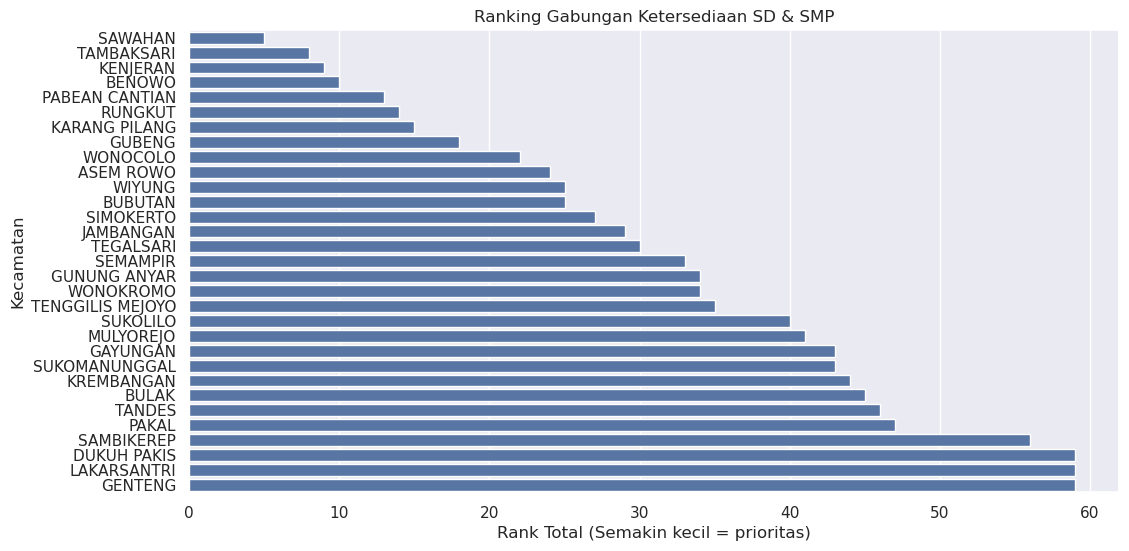

In [26]:
# ==============================
# NORMALISASI (RANKING)
# ==============================

df_agg["Rank_SD"]    = df_agg["Rasio_SD_per_1000"].rank(ascending=True)
df_agg["Rank_SMP"]   = df_agg["Rasio_SMP_per_1000"].rank(ascending=True)
df_agg["Rank_Total"] = df_agg["Rank_SD"] + df_agg["Rank_SMP"]

# ==============================
# NORMALISASI MIN-MAX
# ==============================

df_agg["Norm_SD"] = (
    (df_agg["Rasio_SD_per_1000"] - df_agg["Rasio_SD_per_1000"].min()) /
    (df_agg["Rasio_SD_per_1000"].max() - df_agg["Rasio_SD_per_1000"].min())
)

df_agg["Norm_SMP"] = (
    (df_agg["Rasio_SMP_per_1000"] - df_agg["Rasio_SMP_per_1000"].min()) /
    (df_agg["Rasio_SMP_per_1000"].max() - df_agg["Rasio_SMP_per_1000"].min())
)

# ==============================
# KATEGORISASI
# ==============================

df_agg["Kategori_SD"] = pd.qcut(
    df_agg["Rasio_SD_per_1000"], q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

df_agg["Kategori_SMP"] = pd.qcut(
    df_agg["Rasio_SMP_per_1000"], q=3,
    labels=["Rendah", "Sedang", "Tinggi"]
)

# ==============================
# OUTPUT CEK
# ==============================

df_sorted = df_agg.sort_values("Rank_Total")

print("=== HASIL NORMALISASI & KATEGORI ===")
print(df_sorted[[
    "Kecamatan", "Rasio_SD_per_1000", "Rasio_SMP_per_1000",
    "Rank_SD", "Rank_SMP", "Rank_Total",
    "Kategori_SD", "Kategori_SMP"
]])

# ==============================
# VISUALISASI
# ==============================

sns.barplot(data=df_sorted, x="Rank_Total", y="Kecamatan")
plt.title("Ranking Gabungan Ketersediaan SD & SMP")
plt.xlabel("Rank Total (Semakin kecil = prioritas)")
plt.ylabel("Kecamatan")
plt.savefig("ranking_total.png", bbox_inches="tight", dpi=150)
plt.show()

Hasil normalisasi dan pemeringkatan menunjukkan bahwa kebutuhan peningkatan kapasitas pendidikan di Surabaya tidak merata dan terkonsentrasi pada kecamatan tertentu. Sawahan, Tambaksari, dan Kenjeran muncul sebagai wilayah dengan prioritas tertinggi, didorong oleh kombinasi tekanan kapasitas yang tinggi, ketidakseimbangan antar jenjang, serta rasio sekolah terhadap populasi yang relatif rendah.

Sementara itu, kecamatan seperti Dukuh Pakis, Lakarsantri, dan Genteng menunjukkan kondisi yang lebih stabil dan dapat dijadikan acuan dalam perencanaan distribusi pendidikan yang lebih merata.

Temuan ini menegaskan bahwa pendekatan kebijakan berbasis wilayah menjadi krusial, dengan fokus intervensi yang lebih terarah pada kecamatan dengan tingkat kebutuhan tertinggi, dibandingkan pendekatan seragam di seluruh wilayah kota.

# ======================================
# ANALISIS 17 : HEATMAP KORELASI FINAL
# ======================================

=== MATRIKS KORELASI ===
                       Rasio_SD_per_1000  Rasio_SMP_per_1000  Gap_SD_SMP  \
Rasio_SD_per_1000               1.000000            0.546318   -0.266922   
Rasio_SMP_per_1000              0.546318            1.000000    0.661364   
Gap_SD_SMP                     -0.266922            0.661364    1.000000   
Consistency                     0.315283           -0.299386   -0.626815   
Total Sekolah Inklusi          -0.209020           -0.251747   -0.102480   
Total Siswa Inklusi            -0.208765           -0.145521    0.019516   

                       Consistency  Total Sekolah Inklusi  Total Siswa Inklusi  
Rasio_SD_per_1000         0.315283              -0.209020            -0.208765  
Rasio_SMP_per_1000       -0.299386              -0.251747            -0.145521  
Gap_SD_SMP               -0.626815              -0.102480             0.019516  
Consistency               1.000000               0.027096            -0.002964  
Total Sekolah Inklusi     0.027096   

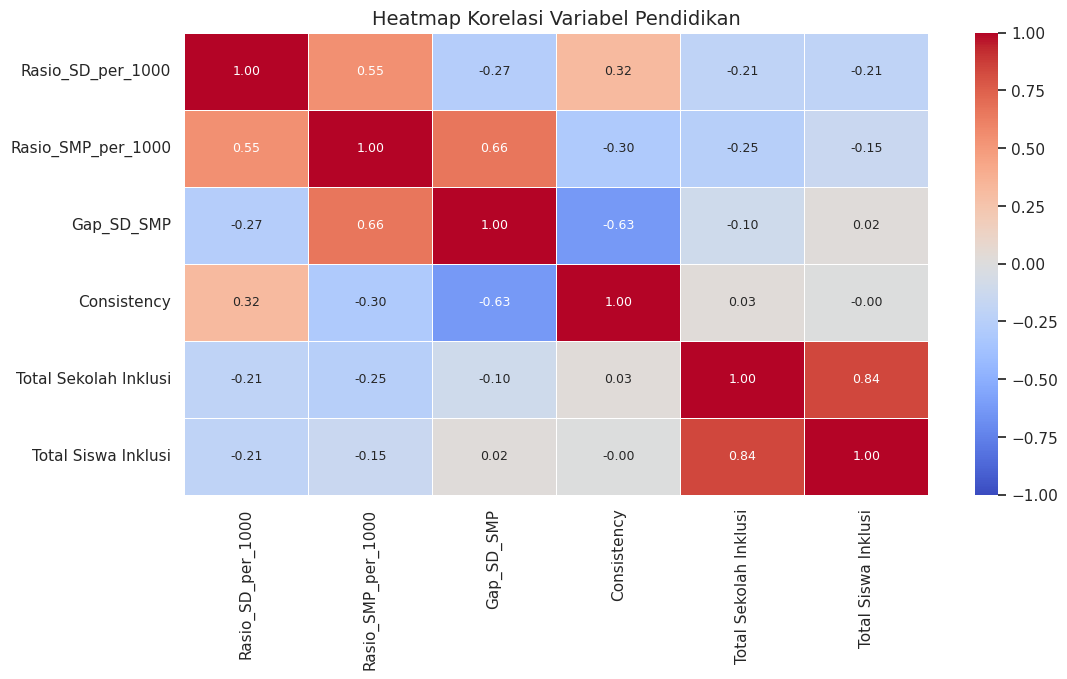

In [27]:
# ==============================
# PILIH VARIABEL PENTING
# ==============================

cols = [
    "Rasio_SD_per_1000",
    "Rasio_SMP_per_1000",
    "Gap_SD_SMP",
    "Consistency",
    "Total Sekolah Inklusi",
    "Total Siswa Inklusi"
]

df_corr = df_agg[cols].corr()

print("=== MATRIKS KORELASI ===")
print(df_corr)

# ==============================
# VISUALISASI HEATMAP
# ==============================

sns.heatmap(
    df_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9}
)

plt.title("Heatmap Korelasi Variabel Pendidikan", fontsize=14)
plt.savefig("heatmap_korelasi_final.png", bbox_inches="tight", dpi=150)
plt.show()

Analisis korelasi menunjukkan bahwa dimensi inklusi dalam sistem pendidikan di Surabaya relatif independen dari kapasitas sekolah secara umum. Tidak terdapat hubungan yang signifikan antara rasio ketersediaan SD maupun SMP dengan jumlah sekolah atau siswa inklusi, mengindikasikan bahwa distribusi pendidikan inklusi lebih dipengaruhi oleh faktor kebijakan atau institusional dibandingkan kapasitas infrastruktur pendidikan.

Sementara itu, hubungan moderat antara rasio SD dan SMP menunjukkan adanya kecenderungan perkembangan yang sejalan antar jenjang, meskipun tidak sepenuhnya konsisten. Hal ini diperkuat oleh korelasi negatif yang kuat antara gap dan konsistensi, yang menandakan bahwa ketidakseimbangan antar jenjang secara langsung menurunkan stabilitas sistem pendidikan di suatu wilayah.

Temuan ini menegaskan bahwa tantangan utama bukan hanya pada peningkatan kapasitas, tetapi pada sinkronisasi pembangunan antar jenjang serta integrasi pendidikan inklusi ke dalam sistem utama.

Korelasi tinggi antara Total Sekolah Inklusi dan Total Siswa Inklusi (0.84) mengkonfirmasi bahwa penambahan sekolah inklusi secara langsung berdampak pada peningkatan akses siswa — menjadikan ekspansi sekolah inklusi sebagai intervensi yang terukur dan terverifikasi efektivitasnya.

# ======================================
# ANALISIS 18 : VALIDASI INSIGHT
# ======================================

In [28]:
from scipy.stats import pearsonr

# ==============================
# VALIDASI KORELASI
# ==============================

print("=== VALIDASI KORELASI (Pearson r + p-value) ===\n")

pairs = [
    ("Rasio_SD_per_1000",  "Total Sekolah Inklusi"),
    ("Rasio_SMP_per_1000", "Total Sekolah Inklusi"),
    ("Rasio_SD_per_1000",  "Total Siswa Inklusi"),
    ("Rasio_SMP_per_1000", "Total Siswa Inklusi"),
    ("Gap_SD_SMP",         "Consistency"),
    ("Rasio_SD_per_1000",  "Rasio_SMP_per_1000"),
]

for x, y in pairs:
    r, p   = pearsonr(df_agg[x], df_agg[y])
    sig    = "✅ Signifikan" if p < 0.05 else "⚠️ Tidak signifikan"
    print(f"{x} vs {y}")
    print(f"  r = {r:.3f} | p-value = {p:.4f} | {sig}")
    print("-" * 50)

# ==============================
# VALIDASI GROUP
# ==============================

print("\n=== RATA-RATA INKLUSI PER KATEGORI SD ===\n")
print(df_agg.groupby("Kategori_SD")["Total Sekolah Inklusi"].mean())

print("\n=== RATA-RATA INKLUSI PER KATEGORI SMP ===\n")
print(df_agg.groupby("Kategori_SMP")["Total Sekolah Inklusi"].mean())

# ==============================
# OUTLIER (Z-SCORE)
# ==============================

print("\n=== OUTLIER (Z-SCORE > 2) ===\n")

df_agg["z_sd"]  = (df_agg["Rasio_SD_per_1000"]  - df_agg["Rasio_SD_per_1000"].mean())  / df_agg["Rasio_SD_per_1000"].std()
df_agg["z_smp"] = (df_agg["Rasio_SMP_per_1000"] - df_agg["Rasio_SMP_per_1000"].mean()) / df_agg["Rasio_SMP_per_1000"].std()

outliers = df_agg[(df_agg["z_sd"].abs() > 2) | (df_agg["z_smp"].abs() > 2)]
print(outliers[["Kecamatan", "Rasio_SD_per_1000", "Rasio_SMP_per_1000"]])

# ==============================
# VALIDASI GAP
# ==============================

print(f"\n=== CEK RATA-RATA GAP ===\n")
print(f"Mean Gap : {df_agg['Gap_SD_SMP'].mean():.3f}")
print(f"Std Gap  : {df_agg['Gap_SD_SMP'].std():.3f}")

# ==============================
# RINGKASAN OTOMATIS
# ==============================

print("\n=== RINGKASAN VALIDASI ===\n")

if abs(df_agg["Rasio_SD_per_1000"].corr(df_agg["Total Sekolah Inklusi"])) < 0.3:
    print("✔ Inklusi tidak berkorelasi kuat dengan SD")

if abs(df_agg["Rasio_SMP_per_1000"].corr(df_agg["Total Sekolah Inklusi"])) < 0.3:
    print("✔ Inklusi tidak berkorelasi kuat dengan SMP")

if df_agg["Gap_SD_SMP"].corr(df_agg["Consistency"]) < -0.5:
    print("✔ Gap berbanding terbalik kuat dengan konsistensi")

if df_agg["Rasio_SD_per_1000"].corr(df_agg["Rasio_SMP_per_1000"]) > 0.4:
    print("✔ SD dan SMP memiliki hubungan moderat")

=== VALIDASI KORELASI (Pearson r + p-value) ===

Rasio_SD_per_1000 vs Total Sekolah Inklusi
  r = -0.209 | p-value = 0.2591 | ⚠️ Tidak signifikan
--------------------------------------------------
Rasio_SMP_per_1000 vs Total Sekolah Inklusi
  r = -0.252 | p-value = 0.1719 | ⚠️ Tidak signifikan
--------------------------------------------------
Rasio_SD_per_1000 vs Total Siswa Inklusi
  r = -0.209 | p-value = 0.2597 | ⚠️ Tidak signifikan
--------------------------------------------------
Rasio_SMP_per_1000 vs Total Siswa Inklusi
  r = -0.146 | p-value = 0.4347 | ⚠️ Tidak signifikan
--------------------------------------------------
Gap_SD_SMP vs Consistency
  r = -0.627 | p-value = 0.0002 | ✅ Signifikan
--------------------------------------------------
Rasio_SD_per_1000 vs Rasio_SMP_per_1000
  r = 0.546 | p-value = 0.0015 | ✅ Signifikan
--------------------------------------------------

=== RATA-RATA INKLUSI PER KATEGORI SD ===

Kategori_SD
Rendah    7.948052
Sedang    5.821429
Tinggi

Validasi statistik menguatkan temuan utama dari analisis sebelumnya. Korelasi antara rasio ketersediaan sekolah (SD maupun SMP) dengan indikator inklusi tidak menunjukkan hubungan yang signifikan secara statistik (p > 0.05), sehingga mengindikasikan bahwa distribusi pendidikan inklusi tidak secara langsung berkaitan dengan kapasitas infrastruktur pendidikan umum.

Sebaliknya, hubungan antara Gap dan Konsistensi terbukti kuat dan signifikan (r = -0.627, p = 0.0002), menunjukkan bahwa ketidakseimbangan antar jenjang berkaitan erat dengan menurunnya konsistensi sistem pendidikan di suatu wilayah.

Lakarsantri dan Sambikerep teridentifikasi sebagai outlier, dengan rasio ketersediaan sekolah yang jauh di atas rata-rata namun dalam arah yang berbeda antar jenjang. Temuan ini konsisten dengan analisis sebelumnya dan memperkuat validitas pola ketidakseimbangan yang telah diidentifikasi.

Rata-rata gap yang bernilai negatif (-0.456) menunjukkan bahwa secara umum kapasitas SMP di Surabaya relatif lebih tertinggal dibandingkan SD, yang mengindikasikan adanya tantangan struktural dalam pemerataan kapasitas antar jenjang pendidikan.

# ======================================
# ANALISIS 19 : KECAMATAN PRIORITAS
# ======================================

=== RANKING PRIORITAS ===

       Kecamatan  Priority_Score  Rasio_SD_per_1000  Rasio_SMP_per_1000  Gap_SD_SMP  Consistency
        KENJERAN            25.9           1.787230            1.654846   -0.132384     0.132384
   KARANG PILANG            25.3           1.888693            1.927608    0.038915     0.038915
      TAMBAKSARI            23.2           1.910696            1.365934   -0.544762     0.544762
          WIYUNG            22.1           2.020457            2.302219    0.281761     0.281761
         RUNGKUT            21.8           2.141960            1.634106   -0.507855     0.507855
         SAWAHAN            21.5           1.981442            1.097781   -0.883661     0.883661
          GUBENG            19.8           2.231971            1.660493   -0.571478     0.571478
    GUNUNG ANYAR            19.6           2.430462            2.485707    0.055245     0.055245
       JAMBANGAN            19.1           1.999000            2.767783    0.768783     0.768783
   

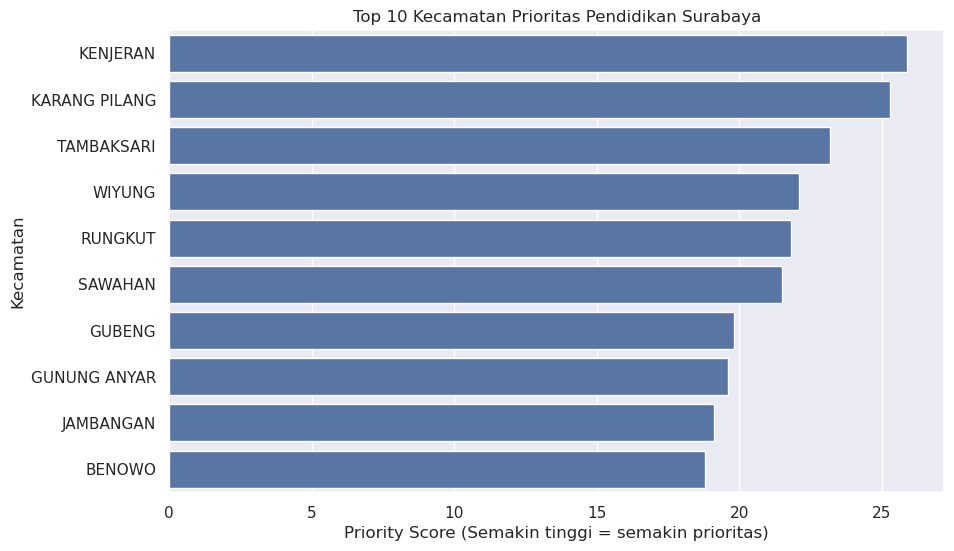


=== SANITY CHECK TOP 5 ===

        Kecamatan  Priority_Score
11       KENJERAN            25.9
10  KARANG PILANG            25.3
24     TAMBAKSARI            23.2
28         WIYUNG            22.1
17        RUNGKUT            21.8


In [29]:
# ==============================
# SCORING (FIXED DIRECTION)
# ==============================

# Besar = buruk = prioritas tinggi

# Rasio kecil = buruk → rank descending
df_agg["Score_SD"] = df_agg["Rasio_SD_per_1000"].rank(ascending=False)
df_agg["Score_SMP"] = df_agg["Rasio_SMP_per_1000"].rank(ascending=False)

# Gap negatif = buruk → rank ascending
df_agg["Score_Gap"] = df_agg["Gap_SD_SMP"].rank(ascending=True)

# Consistency besar = buruk → rank descending
df_agg["Score_Consistency"] = df_agg["Consistency"].rank(ascending=False)

# ==============================
# TOTAL SCORE (WEIGHTED)
# ==============================

df_agg["Priority_Score"] = (
    df_agg["Score_SD"] * 0.3 +
    df_agg["Score_SMP"] * 0.3 +
    df_agg["Score_Gap"] * 0.2 +
    df_agg["Score_Consistency"] * 0.2
)

# ==============================
# SORT PRIORITAS
# ==============================

df_priority = df_agg.sort_values("Priority_Score", ascending=False)

print("=== RANKING PRIORITAS ===\n")
print(df_priority[[
    "Kecamatan",
    "Priority_Score",
    "Rasio_SD_per_1000",
    "Rasio_SMP_per_1000",
    "Gap_SD_SMP",
    "Consistency"
]].to_string(index=False))

# ==============================
# TOP 10
# ==============================

top10 = df_priority.head(10)

print("\n=== TOP 10 KECAMATAN PRIORITAS ===\n")
print(top10[["Kecamatan", "Priority_Score"]].to_string(index=False))

# ==============================
# VISUALISASI BARPLOT
# ==============================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="Priority_Score",
    y="Kecamatan"
)

plt.title("Top 10 Kecamatan Prioritas Pendidikan Surabaya")
plt.xlabel("Priority Score (Semakin tinggi = semakin prioritas)")
plt.ylabel("Kecamatan")

plt.savefig("prioritas_kecamatan.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# SANITY CHECK (OPSIONAL)
# ==============================

print("\n=== SANITY CHECK TOP 5 ===\n")
print(df_priority.head(5)[["Kecamatan", "Priority_Score"]])

## 🎯 Insight Utama

Analisis menunjukkan bahwa prioritas pembangunan pendidikan di Surabaya tidak hanya ditentukan oleh jumlah sekolah, tetapi oleh **kombinasi tekanan kapasitas dan ketidakseimbangan antar jenjang**.

Kecamatan seperti **Kenjeran** dan **Karang Pilang** muncul sebagai prioritas utama karena:
- Rasio sekolah terhadap jumlah anak relatif rendah
- Terdapat ketidakseimbangan antara kapasitas SD dan SMP

Sementara itu, **Tambaksari**, **Wiyung**, dan **Rungkut** menunjukkan tekanan tinggi akibat jumlah anak yang besar.

---

## ⚠️ Temuan Penting

**1. Tekanan kapasitas tidak merata**
Beberapa kecamatan memiliki rasio siswa per sekolah yang tinggi, mengindikasikan potensi kepadatan kelas dan keterbatasan layanan.

**2. Ketidakseimbangan SD vs SMP**
Perbedaan kapasitas antar jenjang menciptakan *bottleneck* saat transisi siswa dan potensi penumpukan di jenjang tertentu.

**3. Prioritas tidak selalu terlihat dari satu indikator**
Beberapa kecamatan tidak ekstrem di satu variabel, tetapi tetap menjadi prioritas ketika semua indikator digabung — menunjukkan pentingnya **pendekatan multi-metrik**.

---

## 🧠 Kesimpulan

Sistem pendidikan Surabaya menunjukkan bahwa:
- Distribusi kapasitas masih belum merata
- Keseimbangan antar jenjang belum sepenuhnya sinkron

Intervensi yang efektif perlu **berbasis wilayah**, mempertimbangkan tekanan kapasitas, serta menjaga keseimbangan antar jenjang pendidikan.

---

## 🗺️ Closing Statement

Untuk melengkapi analisis ini, hasil perhitungan divisualisasikan dalam bentuk **peta choropleth interaktif** — memberikan gambaran spasial kondisi pendidikan dan mempermudah perbandingan antar kecamatan.

### 🧭 Petunjuk Membaca Peta
- **Gradasi warna** — semakin gelap → nilai lebih tinggi (prioritas lebih tinggi)
- **Perbandingan wilayah** — fokus pada kecamatan dengan warna kontras
- **Konteks geografis** — perhatikan apakah ketimpangan terkonsentrasi atau tersebar
- **Interaksi** — *hover* pada kecamatan untuk melihat detail nilai

# ======================================
# ANALISIS 20 : TEKANAN PENDIDIKAN & CLUSTER WILAYAH
# ======================================


# ANALISIS 20 : TEKANAN PENDIDIKAN & CLUSTER WILAYAH

Analisis ini menggabungkan tiga pendekatan untuk memahami kondisi pendidikan secara lebih komprehensif di tingkat kecamatan.

Pendekatan pertama mengukur tekanan kapasitas melalui perbandingan antara jumlah anak usia sekolah dengan jumlah sekolah yang tersedia. Pendekatan kedua menggunakan clustering untuk mengidentifikasi pola kesamaan karakteristik antar wilayah. Pendekatan ketiga memvisualisasikan distribusi spasial melalui peta interaktif.

Sebagai tambahan konteks, analisis ini juga mempertimbangkan rasio fasilitas kesehatan terhadap jumlah anak usia sekolah. Variabel ini tidak digunakan sebagai indikator utama, namun sebagai pembanding untuk melihat apakah tekanan pendidikan berkaitan dengan ketersediaan layanan publik lainnya di suatu wilayah.

Dengan pendekatan ini, analisis tidak hanya menjawab “seberapa besar tekanan yang terjadi”, tetapi juga “bagaimana pola antar wilayah terbentuk” serta “bagaimana posisi wilayah tersebut dalam konteks layanan publik secara lebih luas”.

Ketimpangan pendidikan di Surabaya bukan hanya soal jumlah sekolah, tetapi tentang bagaimana kapasitas tersebut tidak terdistribusi sesuai tekanan populasi dan tidak seimbang antar jenjang.

Analisis ini menunjukkan bahwa permasalahan pendidikan di Surabaya tidak bersifat tunggal, melainkan terdiri dari kombinasi tekanan kapasitas, ketidakseimbangan antar jenjang, serta perbedaan karakteristik wilayah. Pendekatan kebijakan yang seragam berpotensi tidak efektif, karena setiap kecamatan memiliki tipe permasalahan yang berbeda.
Dengan menggabungkan analisis rasio, tekanan, dan clustering, pemetaan ini memberikan gambaran yang lebih utuh mengenai kondisi pendidikan di tingkat kecamatan, sekaligus membantu mengidentifikasi wilayah yang membutuhkan perhatian lebih prioritas.
Untuk melengkapi analisis ini, sebuah peta choropleth interaktif disediakan pada bagian berikutnya, sehingga distribusi prioritas antar kecamatan dapat dilihat secara spasial dan dibandingkan dengan lebih intuitif.

Visualisasi spasial memperkuat temuan bahwa kecamatan dengan tekanan pendidikan tinggi cenderung terkonsentrasi pada wilayah tertentu, bukan tersebar secara merata.

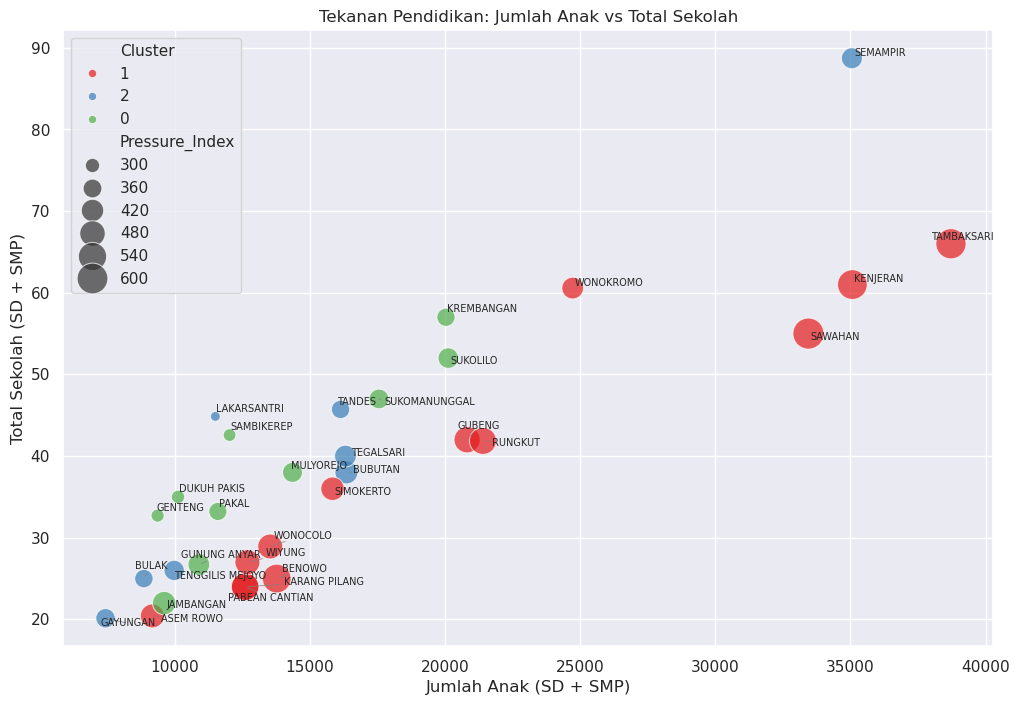

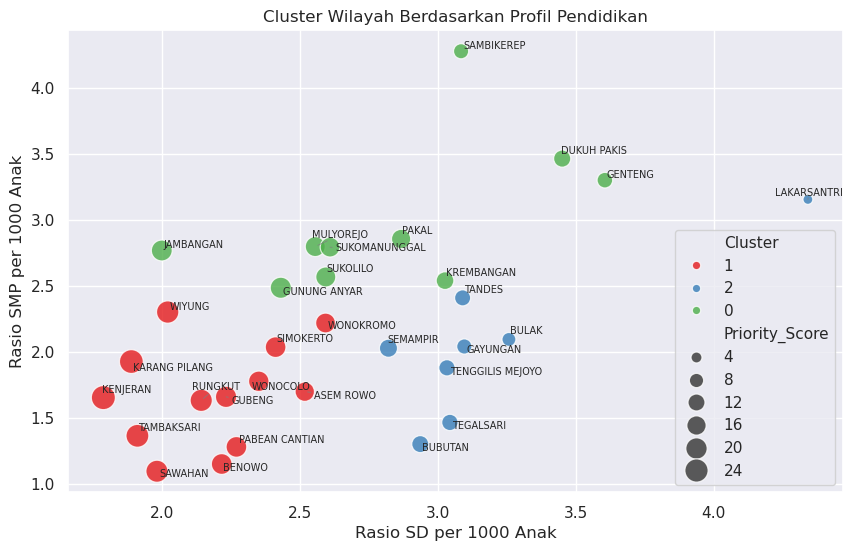

✅ Peta disimpan: peta_pendidikan_faskes.html


In [33]:
# ==============================
# FEATURE ENGINEERING
# ==============================

df_agg["Jumlah_Anak"]    = df_agg["Umur SD"] + df_agg["Umur SMP"]
df_agg["Total_Sekolah"]  = df_agg["Total SD/MI"] + df_agg["Total SMP/MTS"]
df_agg["Pressure_Index"] = df_agg["Jumlah_Anak"] / df_agg["Total_Sekolah"]

# ==============================
# CLUSTERING (K-MEANS)
# ==============================

features = df_agg[[
    "Rasio_SD_per_1000",
    "Rasio_SMP_per_1000",
    "Gap_SD_SMP",
    "Consistency"
]]

scaler            = StandardScaler()
X_scaled          = scaler.fit_transform(features)
kmeans            = KMeans(n_clusters=3, random_state=42, n_init=10)
df_agg["Cluster"] = kmeans.fit_predict(X_scaled).astype(str)

# ==============================
# 1. BUBBLE CHART
# ==============================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_agg,
    x="Jumlah_Anak",
    y="Total_Sekolah",
    size="Pressure_Index",
    hue="Cluster",
    sizes=(50, 500),
    alpha=0.7,
    palette="Set1"
)

texts = []
for i, row in df_agg.iterrows():
    texts.append(plt.text(row["Jumlah_Anak"], row["Total_Sekolah"], row["Kecamatan"], fontsize=7))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title("Tekanan Pendidikan: Jumlah Anak vs Total Sekolah")
plt.xlabel("Jumlah Anak (SD + SMP)")
plt.ylabel("Total Sekolah (SD + SMP)")
plt.savefig("bubble_tekanan.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# 2. SCATTER CLUSTER
# ==============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_agg,
    x="Rasio_SD_per_1000",
    y="Rasio_SMP_per_1000",
    hue="Cluster",
    size="Priority_Score",
    sizes=(50, 300),
    palette="Set1",
    alpha=0.8
)

texts = []
for i, row in df_agg.iterrows():
    texts.append(plt.text(row["Rasio_SD_per_1000"], row["Rasio_SMP_per_1000"], row["Kecamatan"], fontsize=7))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.title("Cluster Wilayah Berdasarkan Profil Pendidikan")
plt.xlabel("Rasio SD per 1000 Anak")
plt.ylabel("Rasio SMP per 1000 Anak")
plt.savefig("scatter_cluster.png", bbox_inches="tight", dpi=150)
plt.show()

# ==============================
# 3. PETA INTERAKTIF
# ==============================

def get_color(score, min_s, max_s):
    ratio = (score - min_s) / (max_s - min_s)
    if ratio < 0.33:   return "green"
    elif ratio < 0.66: return "orange"
    else:              return "red"

min_score = df_agg["Priority_Score"].min()
max_score = df_agg["Priority_Score"].max()

m                = folium.Map(location=[-7.25, 112.75], zoom_start=11)
layer_pendidikan = folium.FeatureGroup(name="Priority Pendidikan")
layer_faskes     = folium.FeatureGroup(name="Fasilitas Kesehatan")

for _, row in df_agg.iterrows():
    if row["Latitude"] != 0 and row["Longitude"] != 0:
        color = get_color(row["Priority_Score"], min_score, max_score)
        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=5 + (row["Priority_Score"] / max_score * 10),
            color=color, fill=True, fill_opacity=0.7,
            tooltip=(
                f"<b>{row['Kecamatan']}</b><br>"
                f"Priority Score : {row['Priority_Score']:.2f}<br>"
                f"Pressure Index : {row['Pressure_Index']:.2f}<br>"
                f"Cluster        : {row['Cluster']}<br>"
                f"Rasio SD       : {row['Rasio_SD_per_1000']:.2f}<br>"
                f"Rasio SMP      : {row['Rasio_SMP_per_1000']:.2f}<br>"
                f"Jumlah Faskes  : {row['Jumlah_Faskes']:.0f}<br>"
                f"Rasio Faskes   : {row['Rasio_Faskes_per_1000_Anak']:.2f}"
            )
        ).add_to(layer_pendidikan)

for _, row in df_agg.iterrows():
    if row["Latitude"] != 0 and row["Longitude"] != 0:
        folium.CircleMarker(
            location=[row["Latitude"], row["Longitude"]],
            radius=3 + (row["Jumlah_Faskes"] * 0.3),
            color="blue", fill=True, fill_opacity=0.5,
            tooltip=(
                f"<b>{row['Kecamatan']}</b><br>"
                f"Jumlah Faskes  : {row['Jumlah_Faskes']:.0f}<br>"
                f"Rasio Faskes   : {row['Rasio_Faskes_per_1000_Anak']:.2f}"
            )
        ).add_to(layer_faskes)

layer_pendidikan.add_to(m)
layer_faskes.add_to(m)
folium.LayerControl().add_to(m)

legend_html = """
<div style="position:fixed; bottom:50px; left:50px; width:200px;
    background-color:white; z-index:9999; font-size:13px;
    border:2px solid grey; border-radius:5px; padding:10px;">
<b>Priority Score</b><br>
<span style="color:green;">●</span> Rendah<br>
<span style="color:orange;">●</span> Sedang<br>
<span style="color:red;">●</span> Tinggi<br><br>
<span style="color:blue;">●</span> Fasilitas Kesehatan
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))
m.save("peta_pendidikan_faskes.html")
print("✅ Peta disimpan: peta_pendidikan_faskes.html")